In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install shapely tqdm

In [3]:
import shutil
import time
from pathlib import Path

DRIVE_ARCHIVE = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/081.선박·해양플랜트 스마트 야드 안전 데이터_세부압축해제.zip"
)

LOCAL_ARCHIVE = Path("/content/labels.zip")

assert DRIVE_ARCHIVE.exists(), DRIVE_ARCHIVE

start = time.time()

shutil.copy2(DRIVE_ARCHIVE, LOCAL_ARCHIVE)

print(f"복사 완료: {(time.time() - start) / 60:.1f}분")
print(f"로컬 파일: {LOCAL_ARCHIVE}")

복사 완료: 1.5분
로컬 파일: /content/labels.zip


In [4]:
import shutil
from pathlib import Path

LOCAL_LABEL_ROOT = Path("/content/smartyard_labels")
LOCAL_LABEL_ROOT.mkdir(parents=True, exist_ok=True)

shutil.unpack_archive(
    "/content/labels.zip",
    LOCAL_LABEL_ROOT
)

print("압축 해제 완료")

압축 해제 완료


In [5]:
from pathlib import Path

DATA_ROOT = Path(
    "/content/smartyard_labels/081.선박·해양플랜트 스마트 야드 안전 데이터/"
    "3.개방데이터/1.데이터"
)

WORK_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace"
)

MANIFEST_ROOT = WORK_ROOT / "manifests"
MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("존재 여부:", DATA_ROOT.exists())

DATA_ROOT: /content/smartyard_labels/081.선박·해양플랜트 스마트 야드 안전 데이터/3.개방데이터/1.데이터
존재 여부: True


In [6]:
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

image_paths = sorted(
    path
    for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

json_paths = sorted(DATA_ROOT.rglob("*.json"))

print("DATA_ROOT:", DATA_ROOT)
print("로컬 경로 여부:", str(DATA_ROOT).startswith("/content/"))
print(f"이미지 수: {len(image_paths):,}")
print(f"JSON 수: {len(json_paths):,}")

print("\n이미지 예시:")
print(image_paths[0] if image_paths else "없음")

print("\nJSON 예시:")
print(json_paths[0] if json_paths else "없음")

DATA_ROOT: /content/smartyard_labels/081.선박·해양플랜트 스마트 야드 안전 데이터/3.개방데이터/1.데이터
로컬 경로 여부: True
이미지 수: 76,966
JSON 수: 76,966

이미지 예시:
/content/smartyard_labels/081.선박·해양플랜트 스마트 야드 안전 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_안전장비-S63_DATA3_안전대미착용-B0/S63_DATA3_B0_L1_D2023-08-25-10-50_001_000254.jpg

JSON 예시:
/content/smartyard_labels/081.선박·해양플랜트 스마트 야드 안전 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_안전장비-S63_DATA3_안전대미착용-B0/S63_DATA3_B0_L1_D2023-08-25-10-50_001_000254.json


In [7]:
import json
import math
import re
import time
import unicodedata
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
from shapely.geometry import Polygon
from shapely.validation import explain_validity
from tqdm.auto import tqdm


# ============================================================
# 0. 경로 확인
# ============================================================

assert "DATA_ROOT" in globals(), "먼저 DATA_ROOT를 설정하세요."
assert DATA_ROOT.exists(), f"DATA_ROOT가 없습니다: {DATA_ROOT}"
assert str(DATA_ROOT).startswith("/content/"), (
    f"DATA_ROOT가 로컬 경로가 아닙니다: {DATA_ROOT}"
)

WORK_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace"
)

MANIFEST_ROOT = WORK_ROOT / "manifests"
MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. 라벨 설정
# ============================================================

def normalize_text(value):
    if not isinstance(value, str):
        return None
    return unicodedata.normalize("NFC", value).strip()


LABEL_MAP = {
    normalize_text("안전모 미착용"): {
        "task_id": "helmet",
        "status_label": 0,
        "class_name": "helmet_off",
        "body_region": "head",
    },
    normalize_text("안전모 착용"): {
        "task_id": "helmet",
        "status_label": 1,
        "class_name": "helmet_on",
        "body_region": "head",
    },
    normalize_text("안전대 미착용"): {
        "task_id": "harness",
        "status_label": 0,
        "class_name": "harness_off",
        "body_region": "torso",
    },
    normalize_text("안전대 착용"): {
        "task_id": "harness",
        "status_label": 1,
        "class_name": "harness_on",
        "body_region": "torso",
    },
    normalize_text("용접마스크 미착용"): {
        "task_id": "welding_mask",
        "status_label": 0,
        "class_name": "welding_mask_off",
        "body_region": "head_face",
    },
    normalize_text("용접마스크 착용"): {
        "task_id": "welding_mask",
        "status_label": 1,
        "class_name": "welding_mask_on",
        "body_region": "head_face",
    },
}

FILE_CODE_MAP = {
    "H0": ("helmet", 0),
    "H1": ("helmet", 1),
    "B0": ("harness", 0),
    "B1": ("harness", 1),
    "M0": ("welding_mask", 0),
    "M1": ("welding_mask", 1),
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

SESSION_PATTERN = re.compile(
    r"^(?P<prefix>.+?)_"
    r"(?P<ppe_code>B0|B1|H0|H1|M0|M1)_"
    r"(?P<level>L\d+)_"
    r"(?P<datetime>D\d{4}-\d{2}-\d{2}-\d{2}-\d{2})_"
    r"(?P<sequence>\d+)_"
    r"(?P<frame>\d+)$"
)


# ============================================================
# 2. 함수
# ============================================================

def load_json(path):
    with Path(path).open("r", encoding="utf-8-sig") as file:
        return json.load(file)


def parse_filename(stem):
    match = SESSION_PATTERN.match(stem)

    if not match:
        return {
            "ppe_code": None,
            "session_id": None,
            "frame_id": None,
            "filename_parse_ok": False,
        }

    values = match.groupdict()

    session_id = (
        f"{values['prefix']}_"
        f"{values['level']}_"
        f"{values['datetime']}_"
        f"{values['sequence']}"
    )

    return {
        "ppe_code": values["ppe_code"],
        "session_id": session_id,
        "frame_id": values["frame"],
        "filename_parse_ok": True,
    }


def infer_original_split(path):
    parts = set(Path(path).parts)

    if "Training" in parts:
        return "Training"

    if "Validation" in parts:
        return "Validation"

    return "Unknown"


def extract_label(annotation):
    categories = annotation.get("categories", [])

    if not isinstance(categories, list) or not categories:
        return None, "missing_categories"

    labels = []

    for category in categories:
        if not isinstance(category, dict):
            continue

        label = normalize_text(category.get("value"))

        if label:
            labels.append(label)

    labels = list(dict.fromkeys(labels))

    if not labels:
        return None, "missing_label"

    if len(labels) != 1:
        return None, "multiple_labels"

    return labels[0], None


def flat_polygon_to_points(flat_polygon):
    if not isinstance(flat_polygon, list):
        return None, "polygon_not_list"

    if not flat_polygon:
        return None, "empty_polygon"

    if len(flat_polygon) % 2 != 0:
        return None, "odd_coordinate_count"

    if len(flat_polygon) < 6:
        return None, "fewer_than_3_points"

    points = []

    for index in range(0, len(flat_polygon), 2):
        x = flat_polygon[index]
        y = flat_polygon[index + 1]

        if not isinstance(x, (int, float)) or not isinstance(y, (int, float)):
            return None, "non_numeric_coordinate"

        x = float(x)
        y = float(y)

        if not math.isfinite(x) or not math.isfinite(y):
            return None, "non_finite_coordinate"

        points.append([x, y])

    return points, None


def validate_polygon(points, width, height):
    unique_points = {
        (round(x, 6), round(y, 6))
        for x, y in points
    }

    if len(unique_points) < 3:
        return False, "fewer_than_3_unique_points", None

    for x, y in points:
        if x < 0 or x > width or y < 0 or y > height:
            return False, "out_of_bounds", [x, y]

    try:
        geometry = Polygon(points)
    except Exception as error:
        return False, "polygon_creation_error", repr(error)

    if geometry.is_empty:
        return False, "empty_geometry", None

    if geometry.area <= 0:
        return False, "zero_area", float(geometry.area)

    if not geometry.is_valid:
        return False, "invalid_polygon", explain_validity(geometry)

    return True, None, float(geometry.area)


def validate_bbox(bbox, width, height):
    if not isinstance(bbox, list) or len(bbox) != 4:
        return None, "missing_or_invalid_bbox"

    if not all(isinstance(value, (int, float)) for value in bbox):
        return None, "non_numeric_bbox"

    x1, y1, x2, y2 = map(float, bbox)

    if x2 <= x1 or y2 <= y1:
        return None, "invalid_bbox_order"

    if x1 < 0 or y1 < 0 or x2 > width or y2 > height:
        return None, "bbox_out_of_bounds"

    return [x1, y1, x2, y2], None


def write_jsonl(records, output_path):
    with Path(output_path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")


# ============================================================
# 3. 이미지·JSON 매칭
# ============================================================

start_time = time.time()

image_paths = sorted(
    path
    for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

json_paths = sorted(DATA_ROOT.rglob("*.json"))

image_map = defaultdict(list)
json_map = defaultdict(list)

for path in image_paths:
    image_map[path.stem].append(path)

for path in json_paths:
    json_map[path.stem].append(path)

duplicate_images = {
    stem: paths
    for stem, paths in image_map.items()
    if len(paths) > 1
}

duplicate_jsons = {
    stem: paths
    for stem, paths in json_map.items()
    if len(paths) > 1
}

assert not duplicate_images, f"중복 이미지 stem: {len(duplicate_images)}"
assert not duplicate_jsons, f"중복 JSON stem: {len(duplicate_jsons)}"

common_stems = sorted(set(image_map) & set(json_map))

print(f"로컬 이미지: {len(image_paths):,}")
print(f"로컬 JSON: {len(json_paths):,}")
print(f"매칭: {len(common_stems):,}")

assert len(common_stems) == 76966, (
    f"예상 매칭 수와 다릅니다: {len(common_stems):,}"
)


# ============================================================
# 4. 전체 정제
# ============================================================

clean_records = []
excluded_records = []
image_summary_records = []
processing_errors = []


for stem in tqdm(common_stems, desc="로컬 JSON 정제"):
    image_path = image_map[stem][0]
    json_path = json_map[stem][0]

    filename_info = parse_filename(stem)
    original_split = infer_original_split(json_path)

    try:
        data = load_json(json_path)

        image_info = data.get("images", {})
        image_width = int(image_info["width"])
        image_height = int(image_info["height"])

    except Exception as error:
        processing_errors.append({
            "stem": stem,
            "json_path": str(json_path),
            "reason": "json_or_metadata_error",
            "detail": repr(error),
        })
        continue

    annotations = data.get("annotations", [])

    if not isinstance(annotations, list) or not annotations:
        excluded_records.append({
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "exclusion_reason": "empty_annotations",
        })

        image_summary_records.append({
            "stem": stem,
            "image_status": "excluded",
            "image_exclusion_reason": "empty_annotations",
        })
        continue

    valid_annotations = []
    bbox_only_count = 0
    invalid_annotations = []

    for annotation_index, annotation in enumerate(annotations):
        label, label_error = extract_label(annotation)

        if label_error:
            invalid_annotations.append({
                "annotation_index": annotation_index,
                "reason": label_error,
            })
            continue

        if label not in LABEL_MAP:
            invalid_annotations.append({
                "annotation_index": annotation_index,
                "reason": "unknown_label",
                "detail": label,
            })
            continue

        flat_polygon = annotation.get("polygon", [])

        if not flat_polygon:
            bbox_only_count += 1
            continue

        points, conversion_error = flat_polygon_to_points(flat_polygon)

        if conversion_error:
            invalid_annotations.append({
                "annotation_index": annotation_index,
                "reason": conversion_error,
            })
            continue

        valid, polygon_error, polygon_detail = validate_polygon(
            points,
            image_width,
            image_height,
        )

        if not valid:
            invalid_annotations.append({
                "annotation_index": annotation_index,
                "reason": polygon_error,
                "detail": polygon_detail,
            })
            continue

        bbox, bbox_warning = validate_bbox(
            annotation.get("bbox"),
            image_width,
            image_height,
        )

        mapping = LABEL_MAP[label]

        valid_annotations.append({
            "annotation_index": annotation_index,
            "object_id": annotation.get("object_id"),
            "object_class": annotation.get("object_class"),
            "source_label": label,
            "task_id": mapping["task_id"],
            "status_label": mapping["status_label"],
            "class_name": mapping["class_name"],
            "body_region": mapping["body_region"],
            "polygon": points,
            "polygon_area": polygon_detail,
            "bbox": bbox,
            "bbox_warning": bbox_warning,
        })

    # 비정상 polygon이 포함된 이미지는 전체 제외
    if invalid_annotations:
        excluded_records.append({
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "exclusion_reason": "contains_invalid_annotation",
            "exclusion_detail": invalid_annotations,
        })

        image_summary_records.append({
            "stem": stem,
            "image_status": "excluded",
            "image_exclusion_reason": "contains_invalid_annotation",
            "valid_polygon_count": len(valid_annotations),
            "bbox_only_count": bbox_only_count,
            "invalid_count": len(invalid_annotations),
        })
        continue

    if not valid_annotations:
        excluded_records.append({
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "exclusion_reason": "no_valid_polygon",
        })

        image_summary_records.append({
            "stem": stem,
            "image_status": "excluded",
            "image_exclusion_reason": "no_valid_polygon",
            "valid_polygon_count": 0,
            "bbox_only_count": bbox_only_count,
            "invalid_count": 0,
        })
        continue

    task_ids = {item["task_id"] for item in valid_annotations}
    status_labels = {item["status_label"] for item in valid_annotations}

    if len(task_ids) != 1 or len(status_labels) != 1:
        reason = (
            "mixed_task_ids"
            if len(task_ids) != 1
            else "mixed_status_labels"
        )

        excluded_records.append({
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "exclusion_reason": reason,
        })
        continue

    task_id = next(iter(task_ids))
    status_label = next(iter(status_labels))

    expected = FILE_CODE_MAP.get(filename_info["ppe_code"])

    if expected is not None and expected != (task_id, status_label):
        excluded_records.append({
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "exclusion_reason": "filename_label_mismatch",
            "expected": list(expected),
            "actual": [task_id, status_label],
        })
        continue

    for annotation in valid_annotations:
        clean_records.append({
            "record_id": (
                f"{stem}__ann_{annotation['annotation_index']:03d}"
            ),
            "stem": stem,
            "image_path": str(image_path),
            "json_path": str(json_path),
            "image_width": image_width,
            "image_height": image_height,

            "task_id": annotation["task_id"],
            "status_label": annotation["status_label"],
            "class_name": annotation["class_name"],
            "source_label": annotation["source_label"],
            "body_region": annotation["body_region"],

            "object_id": annotation["object_id"],
            "object_class": annotation["object_class"],
            "annotation_index": annotation["annotation_index"],

            "annotation_type": "polygon",
            "polygon": annotation["polygon"],
            "polygon_area": annotation["polygon_area"],
            "bbox": annotation["bbox"],
            "bbox_warning": annotation["bbox_warning"],

            "ppe_code": filename_info["ppe_code"],
            "session_id": filename_info["session_id"],
            "frame_id": filename_info["frame_id"],
            "filename_parse_ok": filename_info["filename_parse_ok"],

            "original_split": original_split,
            "source_dataset": "AIHub_SmartYard",
        })

    image_summary_records.append({
        "stem": stem,
        "image_path": str(image_path),
        "json_path": str(json_path),
        "image_width": image_width,
        "image_height": image_height,

        "image_status": "clean",
        "image_exclusion_reason": None,

        "task_id": task_id,
        "status_label": status_label,

        "valid_polygon_count": len(valid_annotations),
        "bbox_only_count": bbox_only_count,
        "invalid_count": 0,

        "ppe_code": filename_info["ppe_code"],
        "session_id": filename_info["session_id"],
        "frame_id": filename_info["frame_id"],
        "original_split": original_split,
    })


# ============================================================
# 5. 저장
# ============================================================

clean_path = MANIFEST_ROOT / "clean_annotation_manifest.jsonl"
excluded_path = MANIFEST_ROOT / "excluded_image_manifest.jsonl"
summary_path = MANIFEST_ROOT / "image_summary_manifest.csv"
errors_path = MANIFEST_ROOT / "processing_errors.jsonl"

write_jsonl(clean_records, clean_path)
write_jsonl(excluded_records, excluded_path)
write_jsonl(processing_errors, errors_path)

summary_df = pd.DataFrame(image_summary_records)
summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# 6. 결과 출력
# ============================================================

elapsed = time.time() - start_time

clean_df = pd.DataFrame(clean_records)
excluded_df = pd.DataFrame(excluded_records)

print("\n" + "=" * 80)
print("정제 완료")
print("=" * 80)

print(f"정상 annotation: {len(clean_df):,}")
print(
    "정상 이미지:",
    int((summary_df["image_status"] == "clean").sum())
)
print(
    "제외 이미지:",
    int((summary_df["image_status"] == "excluded").sum())
)
print(f"처리 오류: {len(processing_errors):,}")
print(f"소요 시간: {elapsed / 60:.2f}분")
print(f"처리 속도: {len(common_stems) / elapsed:.1f}개/초")

print("\n클래스별 정상 annotation")

display(
    clean_df.groupby(
        ["task_id", "status_label", "class_name"]
    )
    .size()
    .reset_index(name="annotation_count")
)

print("\n제외 사유")

display(
    excluded_df["exclusion_reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="image_count")
)

print("\n저장 위치")
print(clean_path)
print(excluded_path)
print(summary_path)
print(errors_path)

로컬 이미지: 76,966
로컬 JSON: 76,966
매칭: 76,966


로컬 JSON 정제:   0%|          | 0/76966 [00:00<?, ?it/s]


정제 완료
정상 annotation: 76,572
정상 이미지: 76363
제외 이미지: 603
처리 오류: 0
소요 시간: 0.74분
처리 속도: 1728.0개/초

클래스별 정상 annotation


,task_id,status_label,class_name,annotation_count
0,harness,0,harness_off,15312
1,harness,1,harness_on,14568
2,helmet,0,helmet_off,15141
3,helmet,1,helmet_on,15360
4,welding_mask,0,welding_mask_off,8403
5,welding_mask,1,welding_mask_on,7788



제외 사유


,reason,image_count
0,contains_invalid_annotation,563
1,empty_annotations,39
2,no_valid_polygon,1



저장 위치
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/clean_annotation_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/excluded_image_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/image_summary_manifest.csv
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/processing_errors.jsonl


In [8]:
import json
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.patches import Rectangle


MANIFEST_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests"
)

CLEAN_MANIFEST_PATH = (
    MANIFEST_ROOT / "clean_annotation_manifest.jsonl"
)


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


clean_records = read_jsonl(CLEAN_MANIFEST_PATH)
clean_df = pd.DataFrame(clean_records)

print(f"불러온 annotation: {len(clean_df):,}")

display(
    clean_df.groupby(
        ["task_id", "status_label", "class_name"]
    )
    .size()
    .reset_index(name="count")
)

불러온 annotation: 76,572


,task_id,status_label,class_name,count
0,harness,0,harness_off,15312
1,harness,1,harness_on,14568
2,helmet,0,helmet_off,15141
3,helmet,1,helmet_on,15360
4,welding_mask,0,welding_mask_off,8403
5,welding_mask,1,welding_mask_on,7788


In [9]:
CLASS_NAME_KR = {
    "helmet_off": "안전모 미착용",
    "helmet_on": "안전모 착용",
    "harness_off": "안전대 미착용",
    "harness_on": "안전대 착용",
    "welding_mask_off": "용접마스크 미착용",
    "welding_mask_on": "용접마스크 착용",
}


def load_image_rgb(image_path):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise FileNotFoundError(
            f"이미지를 읽을 수 없습니다: {image_path}"
        )

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def visualize_record(record, crop_around_polygon=False):
    image_path = Path(record["image_path"])
    image = load_image_rgb(image_path)

    polygon = np.array(
        record["polygon"],
        dtype=np.float32,
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(image)

    polygon_patch = MplPolygon(
        polygon,
        closed=True,
        fill=False,
        linewidth=3,
    )
    ax.add_patch(polygon_patch)

    bbox = record.get("bbox")

    if bbox is not None:
        x1, y1, x2, y2 = bbox

        bbox_patch = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )
        ax.add_patch(bbox_patch)

    title = (
        f"{CLASS_NAME_KR.get(record['class_name'], record['class_name'])}\n"
        f"{record['stem']} | "
        f"polygon area={record['polygon_area']:.1f}"
    )

    ax.set_title(title)
    ax.axis("off")

    if crop_around_polygon:
        x_min = max(float(polygon[:, 0].min()) - 100, 0)
        x_max = min(
            float(polygon[:, 0].max()) + 100,
            record["image_width"],
        )
        y_min = max(float(polygon[:, 1].min()) - 100, 0)
        y_max = min(
            float(polygon[:, 1].max()) + 100,
            record["image_height"],
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)

    plt.show()

In [10]:
random.seed(42)

SAMPLES_PER_CLASS = 5

for class_name in sorted(clean_df["class_name"].unique()):
    class_records = [
        record
        for record in clean_records
        if record["class_name"] == class_name
    ]

    selected_records = random.sample(
        class_records,
        k=min(SAMPLES_PER_CLASS, len(class_records)),
    )

    print("\n" + "=" * 100)
    print(
        CLASS_NAME_KR.get(class_name, class_name),
        f"전체 annotation: {len(class_records):,}",
    )
    print("=" * 100)

    for record in selected_records:
        visualize_record(
            record,
            crop_around_polygon=False,
        )

        visualize_record(
            record,
            crop_around_polygon=True,
        )

Output hidden; open in https://colab.research.google.com to view.

In [11]:
clean_df["polygon_area_ratio"] = (
    clean_df["polygon_area"]
    / (
        clean_df["image_width"]
        * clean_df["image_height"]
    )
)

small_samples_df = (
    clean_df
    .sort_values("polygon_area_ratio")
    .groupby("class_name", group_keys=False)
    .head(3)
)

for _, row in small_samples_df.iterrows():
    print(
        row["class_name"],
        f"area ratio={row['polygon_area_ratio']:.8f}",
    )

    visualize_record(
        row.to_dict(),
        crop_around_polygon=True,
    )

Output hidden; open in https://colab.research.google.com to view.

In [12]:
import pandas as pd
from pathlib import Path

SUMMARY_PATH = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/"
    "image_summary_manifest.csv"
)

summary_df = pd.read_csv(SUMMARY_PATH)

clean_df = summary_df[
    summary_df["image_status"] == "clean"
].copy()

print(f"정상 이미지: {len(clean_df):,}")
print(f"세션 키 누락: {clean_df['session_id'].isna().sum():,}")
print(f"고유 세션 수: {clean_df['session_id'].nunique():,}")

session_stats = (
    clean_df.groupby("session_id")
    .agg(
        image_count=("stem", "count"),
        task_count=("task_id", "nunique"),
        code_count=("ppe_code", "nunique"),
        tasks=("task_id", lambda x: sorted(set(x))),
        codes=("ppe_code", lambda x: sorted(set(x))),
    )
    .reset_index()
)

print("\n세션당 이미지 수 통계")
display(session_stats["image_count"].describe())

print("\n이미지가 가장 많은 세션")
display(
    session_stats
    .sort_values("image_count", ascending=False)
    .head(20)
)

print("\n여러 PPE task가 함께 묶인 세션 수")
print((session_stats["task_count"] > 1).sum())

display(
    session_stats[
        session_stats["task_count"] > 1
    ].head(20)
)

정상 이미지: 76,363
세션 키 누락: 0
고유 세션 수: 72

세션당 이미지 수 통계


,image_count
count,72.000000
mean,1060.597222
std,901.865573
min,16.000000
25%,456.500000
50%,816.000000
75%,1393.000000
max,5416.000000



이미지가 가장 많은 세션


,session_id,image_count,task_count,code_count,tasks,codes
59,S63_DATA3_L1_D2023-10-25-15-40_045,5416,1,1,[helmet],[H0]
54,S63_DATA3_L1_D2023-10-25-13-35_001,3385,1,1,[helmet],[H1]
42,S63_DATA3_L1_D2023-10-12-14-13_042,3016,1,1,[welding_mask],[M0]
71,S63_DATA3_L3_D2023-08-16-14-10_001,2620,1,1,[welding_mask],[M1]
52,S63_DATA3_L1_D2023-10-25-13-25_001,2428,1,1,[helmet],[H1]
10,S63_DATA3_L1_D2023-08-25-16-49_001,2258,1,1,[welding_mask],[M0]
14,S63_DATA3_L1_D2023-09-07-13-24_001,2201,1,1,[harness],[B0]
60,S63_DATA3_L1_D2023-10-25-15-45_043,2171,1,1,[helmet],[H0]
55,S63_DATA3_L1_D2023-10-25-13-40_001,2066,1,1,[helmet],[H1]
12,S63_DATA3_L1_D2023-09-07-13-12_001,1996,1,1,[harness],[B0]



여러 PPE task가 함께 묶인 세션 수
0


,session_id,image_count,task_count,code_count,tasks,codes


In [13]:
import json
from pathlib import Path

import numpy as np
import pandas as pd


MANIFEST_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests"
)

SUMMARY_PATH = MANIFEST_ROOT / "image_summary_manifest.csv"
CLEAN_ANNOTATION_PATH = MANIFEST_ROOT / "clean_annotation_manifest.jsonl"

SPLIT_OUTPUT_ROOT = MANIFEST_ROOT / "splits"
SPLIT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


# 정상 이미지만 사용
summary_df = pd.read_csv(SUMMARY_PATH)

clean_images_df = summary_df[
    summary_df["image_status"] == "clean"
].copy()

required_columns = [
    "stem",
    "session_id",
    "ppe_code",
    "task_id",
    "status_label",
    "image_path",
    "json_path",
]

missing_columns = [
    column
    for column in required_columns
    if column not in clean_images_df.columns
]

assert not missing_columns, f"누락된 열: {missing_columns}"
assert clean_images_df["session_id"].notna().all()
assert clean_images_df["ppe_code"].notna().all()


PPE_CODES = ["B0", "B1", "H0", "H1", "M0", "M1"]
SPLITS = ["train", "val", "test"]

SPLIT_RATIOS = {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1,
}


# 세션별 PPE 코드 이미지 수 행렬
session_code_matrix = pd.crosstab(
    clean_images_df["session_id"],
    clean_images_df["ppe_code"],
)

for code in PPE_CODES:
    if code not in session_code_matrix.columns:
        session_code_matrix[code] = 0

session_code_matrix = session_code_matrix[PPE_CODES]
session_code_matrix["total"] = session_code_matrix.sum(axis=1)
session_code_matrix = session_code_matrix.reset_index()


print(f"정상 이미지: {len(clean_images_df):,}")
print(f"고유 세션: {len(session_code_matrix):,}")

print("\n전체 코드별 이미지 수")
display(
    clean_images_df["ppe_code"]
    .value_counts()
    .reindex(PPE_CODES)
    .rename_axis("ppe_code")
    .reset_index(name="image_count")
)

print("\n세션 통계 예시")
display(
    session_code_matrix
    .sort_values("total", ascending=False)
    .head(15)
)

정상 이미지: 76,363
고유 세션: 72

전체 코드별 이미지 수


,ppe_code,image_count
0,B0,15312
1,B1,14567
2,H0,15141
3,H1,15152
4,M0,8403
5,M1,7788



세션 통계 예시


ppe_code,session_id,B0,B1,H0,H1,M0,M1,total
59,S63_DATA3_L1_D2023-10-25-15-40_045,0,0,5416,0,0,0,5416
54,S63_DATA3_L1_D2023-10-25-13-35_001,0,0,0,3385,0,0,3385
42,S63_DATA3_L1_D2023-10-12-14-13_042,0,0,0,0,3016,0,3016
71,S63_DATA3_L3_D2023-08-16-14-10_001,0,0,0,0,0,2620,2620
52,S63_DATA3_L1_D2023-10-25-13-25_001,0,0,0,2428,0,0,2428
10,S63_DATA3_L1_D2023-08-25-16-49_001,0,0,0,0,2258,0,2258
14,S63_DATA3_L1_D2023-09-07-13-24_001,2201,0,0,0,0,0,2201
60,S63_DATA3_L1_D2023-10-25-15-45_043,0,0,2171,0,0,0,2171
55,S63_DATA3_L1_D2023-10-25-13-40_001,0,0,0,2066,0,0,2066
12,S63_DATA3_L1_D2023-09-07-13-12_001,1996,0,0,0,0,0,1996


In [14]:
from collections import defaultdict


FEATURE_COLUMNS = PPE_CODES + ["total"]

session_ids = session_code_matrix["session_id"].tolist()

session_vectors = {
    row["session_id"]: np.array(
        [float(row[column]) for column in FEATURE_COLUMNS],
        dtype=np.float64,
    )
    for _, row in session_code_matrix.iterrows()
}

global_totals = np.array(
    [
        float((clean_images_df["ppe_code"] == code).sum())
        for code in PPE_CODES
    ]
    + [float(len(clean_images_df))],
    dtype=np.float64,
)

target_counts = {
    split: global_totals * SPLIT_RATIOS[split]
    for split in SPLITS
}


def calculate_score(split_counts):
    """
    각 코드와 전체 이미지 수의 목표 비율 오차를 계산한다.
    값이 낮을수록 좋다.
    """
    score = 0.0

    for split in SPLITS:
        target = target_counts[split]
        actual = split_counts[split]

        normalized_error = (
            (actual - target)
            / np.maximum(target, 1.0)
        )

        # 코드별 분포와 전체 이미지 수를 모두 반영
        score += float(np.sum(normalized_error ** 2))

        # 목표를 크게 초과하는 split에 추가 페널티
        overshoot = np.maximum(actual - target, 0)
        score += 0.2 * float(
            np.sum(
                (
                    overshoot
                    / np.maximum(target, 1.0)
                ) ** 2
            )
        )

    return score


def all_codes_exist(assignments):
    """
    train/val/test 모두 B0~M1 코드를 최소 1장 이상 포함하는지 검사한다.
    """
    code_presence = {
        split: {code: 0 for code in PPE_CODES}
        for split in SPLITS
    }

    for session_id, split in assignments.items():
        vector = session_vectors[session_id]

        for index, code in enumerate(PPE_CODES):
            code_presence[split][code] += int(vector[index])

    return all(
        code_presence[split][code] > 0
        for split in SPLITS
        for code in PPE_CODES
    )


def greedy_assignment(random_seed):
    rng = np.random.default_rng(random_seed)

    # 큰 세션부터 배정하되 같은 크기끼리는 무작위성을 부여
    ordered_sessions = sorted(
        session_ids,
        key=lambda session_id: (
            -session_vectors[session_id][-1],
            rng.random(),
        ),
    )

    split_counts = {
        split: np.zeros(len(FEATURE_COLUMNS), dtype=np.float64)
        for split in SPLITS
    }

    assignments = {}

    # 각 split이 비어 있지 않게 가장 큰 세션 3개를 우선 배정
    initial_splits = ["train", "val", "test"]

    for session_id, split in zip(
        ordered_sessions[:3],
        initial_splits,
    ):
        assignments[session_id] = split
        split_counts[split] += session_vectors[session_id]

    for session_id in ordered_sessions[3:]:
        candidate_scores = []

        candidate_split_order = list(SPLITS)
        rng.shuffle(candidate_split_order)

        for split in candidate_split_order:
            test_counts = {
                name: values.copy()
                for name, values in split_counts.items()
            }

            test_counts[split] += session_vectors[session_id]

            score = calculate_score(test_counts)

            candidate_scores.append((score, split))

        _, best_split = min(candidate_scores, key=lambda item: item[0])

        assignments[session_id] = best_split
        split_counts[best_split] += session_vectors[session_id]

    return assignments, split_counts


def local_improvement(assignments, split_counts, max_rounds=100):
    """
    한 세션씩 다른 split으로 이동해 점수를 추가 개선한다.
    """
    current_score = calculate_score(split_counts)

    for _ in range(max_rounds):
        improved = False

        for session_id in np.random.permutation(session_ids):
            current_split = assignments[session_id]
            vector = session_vectors[session_id]

            for candidate_split in SPLITS:
                if candidate_split == current_split:
                    continue

                # 현재 split에 세션이 하나만 남는 이동은 금지
                current_split_session_count = sum(
                    split == current_split
                    for split in assignments.values()
                )

                if current_split_session_count <= 1:
                    continue

                test_counts = {
                    name: values.copy()
                    for name, values in split_counts.items()
                }

                test_counts[current_split] -= vector
                test_counts[candidate_split] += vector

                new_score = calculate_score(test_counts)

                if new_score < current_score:
                    assignments[session_id] = candidate_split
                    split_counts = test_counts
                    current_score = new_score
                    improved = True
                    current_split = candidate_split
                    break

        if not improved:
            break

    return assignments, split_counts, current_score


BEST_ASSIGNMENTS = None
BEST_COUNTS = None
BEST_SCORE = float("inf")

RANDOM_RESTARTS = 500

for seed in range(RANDOM_RESTARTS):
    assignments, counts = greedy_assignment(seed)

    assignments, counts, score = local_improvement(
        assignments,
        counts,
        max_rounds=50,
    )

    if not all_codes_exist(assignments):
        continue

    if score < BEST_SCORE:
        BEST_ASSIGNMENTS = assignments.copy()
        BEST_COUNTS = {
            split: values.copy()
            for split, values in counts.items()
        }
        BEST_SCORE = score


assert BEST_ASSIGNMENTS is not None, (
    "조건을 만족하는 split을 찾지 못했습니다. "
    "RANDOM_RESTARTS를 늘려보세요."
)

print("분할 최적화 완료")
print("최종 score:", BEST_SCORE)
print("배정 세션 수:", len(BEST_ASSIGNMENTS))

분할 최적화 완료
최종 score: 2.2223062624021233
배정 세션 수: 72


In [15]:
session_split_df = session_code_matrix.copy()

session_split_df["new_split"] = (
    session_split_df["session_id"]
    .map(BEST_ASSIGNMENTS)
)

assert session_split_df["new_split"].notna().all()


print("Split별 세션 수")

display(
    session_split_df["new_split"]
    .value_counts()
    .reindex(SPLITS)
    .rename_axis("split")
    .reset_index(name="session_count")
)


split_code_counts = (
    session_split_df
    .groupby("new_split")[FEATURE_COLUMNS]
    .sum()
    .reindex(SPLITS)
)

print("\nSplit별 이미지 수와 코드 분포")
display(split_code_counts)


split_ratio_df = (
    split_code_counts
    .div(global_totals, axis=1)
    .multiply(100)
)

print("\n전체 데이터 대비 split별 비율(%)")
display(split_ratio_df.round(2))

Split별 세션 수


,split,session_count
0,train,56
1,val,7
2,test,9



Split별 이미지 수와 코드 분포


ppe_code,B0,B1,H0,H1,M0,M1,total
new_split,,,,,,,
train,11115,10896,12323,11180,5832,5794,57140
val,2201,1850,1384,2428,1151,1178,10192
test,1996,1821,1434,1544,1420,816,9031



전체 데이터 대비 split별 비율(%)


ppe_code,B0,B1,H0,H1,M0,M1,total
new_split,,,,,,,
train,72.59,74.8,81.39,73.79,69.4,74.40,74.83
val,14.37,12.7,9.14,16.02,13.7,15.13,13.35
test,13.04,12.5,9.47,10.19,16.9,10.48,11.83


In [16]:
# 이미지 manifest에 new_split 추가
image_split_df = clean_images_df.copy()

image_split_df["new_split"] = (
    image_split_df["session_id"]
    .map(BEST_ASSIGNMENTS)
)

assert image_split_df["new_split"].notna().all()


# ------------------------------------------------------------
# 1. 세션 누수 검사
# ------------------------------------------------------------

session_split_count = (
    image_split_df
    .groupby("session_id")["new_split"]
    .nunique()
)

leaked_sessions = session_split_count[
    session_split_count > 1
]

assert len(leaked_sessions) == 0, (
    f"세션 누수 발견: {len(leaked_sessions)}"
)


# ------------------------------------------------------------
# 2. 클래스 존재 검사
# ------------------------------------------------------------

code_distribution = pd.crosstab(
    image_split_df["new_split"],
    image_split_df["ppe_code"],
).reindex(
    index=SPLITS,
    columns=PPE_CODES,
    fill_value=0,
)

assert (code_distribution > 0).all().all(), (
    "일부 split에 없는 PPE 코드가 있습니다."
)


# ------------------------------------------------------------
# 3. 이미지 split manifest 저장
# ------------------------------------------------------------

SESSION_SPLIT_PATH = (
    SPLIT_OUTPUT_ROOT / "session_split_map.csv"
)

IMAGE_SPLIT_PATH = (
    SPLIT_OUTPUT_ROOT / "image_split_manifest.csv"
)

session_split_df.to_csv(
    SESSION_SPLIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

image_split_df.to_csv(
    IMAGE_SPLIT_PATH,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 4. Annotation manifest에도 new_split 추가
# ------------------------------------------------------------

def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


def write_jsonl(records, path):
    with Path(path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(record, ensure_ascii=False)
                + "\n"
            )


annotation_records = read_jsonl(CLEAN_ANNOTATION_PATH)

split_annotation_records = {
    "train": [],
    "val": [],
    "test": [],
}

all_annotation_records = []

for record in annotation_records:
    session_id = record["session_id"]

    new_split = BEST_ASSIGNMENTS.get(session_id)

    if new_split is None:
        raise KeyError(
            f"split이 없는 session_id: {session_id}"
        )

    updated_record = dict(record)
    updated_record["new_split"] = new_split

    all_annotation_records.append(updated_record)
    split_annotation_records[new_split].append(updated_record)


ALL_SPLIT_ANNOTATION_PATH = (
    SPLIT_OUTPUT_ROOT
    / "clean_annotation_manifest_with_split.jsonl"
)

write_jsonl(
    all_annotation_records,
    ALL_SPLIT_ANNOTATION_PATH,
)

for split in SPLITS:
    output_path = (
        SPLIT_OUTPUT_ROOT
        / f"{split}_annotation_manifest.jsonl"
    )

    write_jsonl(
        split_annotation_records[split],
        output_path,
    )


# ------------------------------------------------------------
# 5. 최종 검증 결과
# ------------------------------------------------------------

print("=" * 80)
print("세션 단위 분할 완료")
print("=" * 80)

print(f"전체 이미지: {len(image_split_df):,}")
print(f"전체 annotation: {len(all_annotation_records):,}")
print(f"세션 누수: {len(leaked_sessions)}")

print("\nSplit별 이미지 수")

split_image_counts = (
    image_split_df["new_split"]
    .value_counts()
    .reindex(SPLITS)
)

display(
    split_image_counts
    .rename_axis("split")
    .reset_index(name="image_count")
)

print("\nSplit별 이미지 비율")

display(
    (
        split_image_counts
        / len(image_split_df)
        * 100
    )
    .round(2)
    .rename_axis("split")
    .reset_index(name="ratio_percent")
)

print("\nSplit별 PPE 코드 수")

display(code_distribution)

print("\nSplit별 annotation 수")

annotation_count_rows = []

for split in SPLITS:
    split_records = split_annotation_records[split]

    split_df = pd.DataFrame(split_records)

    grouped = (
        split_df.groupby(
            [
                "task_id",
                "status_label",
                "class_name",
            ]
        )
        .size()
        .reset_index(name="annotation_count")
    )

    grouped.insert(0, "split", split)
    annotation_count_rows.append(grouped)

annotation_distribution_df = pd.concat(
    annotation_count_rows,
    ignore_index=True,
)

display(annotation_distribution_df)


print("\n저장 파일")
print(SESSION_SPLIT_PATH)
print(IMAGE_SPLIT_PATH)
print(ALL_SPLIT_ANNOTATION_PATH)

for split in SPLITS:
    print(
        SPLIT_OUTPUT_ROOT
        / f"{split}_annotation_manifest.jsonl"
    )

세션 단위 분할 완료
전체 이미지: 76,363
전체 annotation: 76,572
세션 누수: 0

Split별 이미지 수


,split,image_count
0,train,57140
1,val,10192
2,test,9031



Split별 이미지 비율


,split,ratio_percent
0,train,74.83
1,val,13.35
2,test,11.83



Split별 PPE 코드 수


ppe_code,B0,B1,H0,H1,M0,M1
new_split,,,,,,
train,11115,10896,12323,11180,5832,5794
val,2201,1850,1384,2428,1151,1178
test,1996,1821,1434,1544,1420,816



Split별 annotation 수


,split,task_id,status_label,class_name,annotation_count
0,train,harness,0,harness_off,11115
1,train,harness,1,harness_on,10896
2,train,helmet,0,helmet_off,12323
3,train,helmet,1,helmet_on,11334
4,train,welding_mask,0,welding_mask_off,5832
5,train,welding_mask,1,welding_mask_on,5794
6,val,harness,0,harness_off,2201
7,val,harness,1,harness_on,1851
8,val,helmet,0,helmet_off,1384
9,val,helmet,1,helmet_on,2428



저장 파일
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/session_split_map.csv
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/image_split_manifest.csv
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/clean_annotation_manifest_with_split.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/train_annotation_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/val_annotation_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/test_annotation_manifest.jsonl


In [17]:
import json
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd


SPLIT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits"
)

MINI_ROOT = SPLIT_ROOT / "mini"
MINI_ROOT.mkdir(parents=True, exist_ok=True)

SAMPLE_LIMITS = {
    "train": 500,
    "val": 150,
    "test": 150,
}

CLASS_NAMES = [
    "harness_off",
    "harness_on",
    "helmet_off",
    "helmet_on",
    "welding_mask_off",
    "welding_mask_on",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


def write_jsonl(records, path):
    with Path(path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )


def sample_diverse_records(records, max_count, seed=42):
    """
    여러 세션의 이미지가 골고루 포함되도록 라운드로빈 방식으로 추출한다.
    동일 이미지에 polygon이 여러 개 있으면 annotation 단위로 유지한다.
    """

    rng = random.Random(seed)

    records_by_session = defaultdict(list)

    for record in records:
        records_by_session[record["session_id"]].append(record)

    # 각 세션 내부 순서 무작위화
    for session_records in records_by_session.values():
        rng.shuffle(session_records)

    session_ids = list(records_by_session.keys())
    rng.shuffle(session_ids)

    sampled = []

    # 한 세션에서 한 장씩 순환 추출
    while len(sampled) < max_count:
        added = False

        for session_id in session_ids:
            if len(sampled) >= max_count:
                break

            session_records = records_by_session[session_id]

            if session_records:
                sampled.append(session_records.pop())
                added = True

        if not added:
            break

        rng.shuffle(session_ids)

    return sampled


all_mini_records = []
summary_rows = []

for split_index, split in enumerate(["train", "val", "test"]):
    source_path = (
        SPLIT_ROOT / f"{split}_annotation_manifest.jsonl"
    )

    split_records = read_jsonl(source_path)

    selected_split_records = []

    for class_index, class_name in enumerate(CLASS_NAMES):
        class_records = [
            record
            for record in split_records
            if record["class_name"] == class_name
        ]

        selected_records = sample_diverse_records(
            records=class_records,
            max_count=SAMPLE_LIMITS[split],
            seed=(
                RANDOM_SEED
                + split_index * 100
                + class_index
            ),
        )

        selected_split_records.extend(selected_records)

        summary_rows.append({
            "split": split,
            "class_name": class_name,
            "available_annotations": len(class_records),
            "selected_annotations": len(selected_records),
            "selected_sessions": len({
                record["session_id"]
                for record in selected_records
            }),
            "selected_images": len({
                record["stem"]
                for record in selected_records
            }),
        })

    # 최종 순서 무작위화
    random.Random(
        RANDOM_SEED + split_index
    ).shuffle(selected_split_records)

    output_path = (
        MINI_ROOT / f"mini_{split}_manifest.jsonl"
    )

    write_jsonl(
        selected_split_records,
        output_path,
    )

    all_mini_records.extend(selected_split_records)


all_output_path = (
    MINI_ROOT / "mini_all_manifest.jsonl"
)

write_jsonl(
    all_mini_records,
    all_output_path,
)


summary_df = pd.DataFrame(summary_rows)

summary_path = (
    MINI_ROOT / "mini_manifest_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig",
)


print("=" * 80)
print("Mini manifest 생성 완료")
print("=" * 80)

display(summary_df)

print("\nSplit별 선택 annotation 수")

display(
    summary_df.groupby("split")["selected_annotations"]
    .sum()
    .reset_index()
)

print("\n저장 위치")

for path in sorted(MINI_ROOT.iterdir()):
    print(path)

Mini manifest 생성 완료


,split,class_name,available_annotations,selected_annotations,selected_sessions,selected_images
0,train,harness_off,11115,500,13,500
1,train,harness_on,10896,500,20,500
2,train,helmet_off,12323,500,10,500
3,train,helmet_on,11334,500,10,499
4,train,welding_mask_off,5832,500,3,500
5,train,welding_mask_on,5794,500,4,500
6,val,harness_off,2201,150,1,150
7,val,harness_on,1851,150,1,150
8,val,helmet_off,1384,150,2,150
9,val,helmet_on,2428,150,1,150



Split별 선택 annotation 수


,split,selected_annotations
0,test,900
1,train,3000
2,val,900



저장 위치
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/mini/mini_all_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/mini/mini_manifest_summary.csv
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/mini/mini_test_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/mini/mini_train_manifest.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/splits/mini/mini_val_manifest.jsonl


In [18]:
import json
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF


MINI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits/mini"
)

TRAIN_MANIFEST = MINI_ROOT / "mini_train_manifest.jsonl"
VAL_MANIFEST = MINI_ROOT / "mini_val_manifest.jsonl"
TEST_MANIFEST = MINI_ROOT / "mini_test_manifest.jsonl"

IMAGE_SIZE = 512

TASK_TO_INDEX = {
    "helmet": 0,
    "harness": 1,
    "welding_mask": 2,
}

INDEX_TO_TASK = {
    value: key
    for key, value in TASK_TO_INDEX.items()
}


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


class PPESegmentationDataset(Dataset):
    def __init__(
        self,
        manifest_path,
        image_size=512,
        augment=False,
    ):
        self.records = read_jsonl(manifest_path)
        self.image_size = image_size
        self.augment = augment

        if len(self.records) == 0:
            raise ValueError(
                f"Manifest에 데이터가 없습니다: {manifest_path}"
            )

    def __len__(self):
        return len(self.records)

    def _make_mask(self, record):
        height = int(record["image_height"])
        width = int(record["image_width"])

        mask = np.zeros(
            (height, width),
            dtype=np.uint8,
        )

        polygon = np.asarray(
            record["polygon"],
            dtype=np.float32,
        )

        polygon = np.round(polygon).astype(np.int32)

        cv2.fillPoly(
            mask,
            [polygon],
            color=1,
        )

        return mask

    def _resize(self, image, mask):
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        return image, mask

    def _apply_augmentation(self, image, mask):
        # 좌우 반전만 우선 적용
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[:, ::-1])
            mask = np.ascontiguousarray(mask[:, ::-1])

        return image, mask

    def __getitem__(self, index):
        record = self.records[index]

        image_path = Path(record["image_path"])

        image_bgr = cv2.imread(str(image_path))

        if image_bgr is None:
            raise FileNotFoundError(
                f"이미지를 읽을 수 없습니다: {image_path}"
            )

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        mask = self._make_mask(record)

        image_rgb, mask = self._resize(
            image_rgb,
            mask,
        )

        if self.augment:
            image_rgb, mask = self._apply_augmentation(
                image_rgb,
                mask,
            )

        image_tensor = torch.from_numpy(
            image_rgb.copy()
        ).permute(2, 0, 1).float() / 255.0

        # ImageNet 정규화
        image_tensor = TF.normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        mask_tensor = torch.from_numpy(
            mask.copy()
        ).float().unsqueeze(0)

        mask_tensor = (
            mask_tensor > 0.5
        ).float()

        task_id = record["task_id"]
        task_index = TASK_TO_INDEX[task_id]

        status_label = int(record["status_label"])

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "task_index": torch.tensor(
                task_index,
                dtype=torch.long,
            ),
            "status_label": torch.tensor(
                status_label,
                dtype=torch.long,
            ),
            "class_name": record["class_name"],
            "stem": record["stem"],
            "image_path": str(image_path),
        }


train_dataset = PPESegmentationDataset(
    TRAIN_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=True,
)

val_dataset = PPESegmentationDataset(
    VAL_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

test_dataset = PPESegmentationDataset(
    TEST_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3000
Validation: 900
Test: 900


In [19]:
import matplotlib.pyplot as plt


batch = next(iter(train_loader))

print("image:", batch["image"].shape)
print("mask:", batch["mask"].shape)
print("task_index:", batch["task_index"].shape)
print("status_label:", batch["status_label"].shape)


def denormalize_image(image_tensor):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


sample_count = min(4, batch["image"].shape[0])

for index in range(sample_count):
    image = denormalize_image(
        batch["image"][index]
    )

    mask = (
        batch["mask"][index, 0]
        .cpu()
        .numpy()
    )

    task_name = INDEX_TO_TASK[
        int(batch["task_index"][index])
    ]

    status_label = int(
        batch["status_label"][index]
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
    )

    axes[0].imshow(image)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(mask)
    axes[1].set_title("Ground-truth mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(
        mask,
        alpha=0.45,
    )
    axes[2].set_title(
        f"{task_name} / status={status_label}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [20]:
import json
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF


MINI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits/mini"
)

TRAIN_MANIFEST = MINI_ROOT / "mini_train_manifest.jsonl"
VAL_MANIFEST = MINI_ROOT / "mini_val_manifest.jsonl"
TEST_MANIFEST = MINI_ROOT / "mini_test_manifest.jsonl"

IMAGE_SIZE = 512

TASK_TO_INDEX = {
    "helmet": 0,
    "harness": 1,
    "welding_mask": 2,
}

INDEX_TO_TASK = {
    value: key
    for key, value in TASK_TO_INDEX.items()
}


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


class PPESegmentationDataset(Dataset):
    def __init__(
        self,
        manifest_path,
        image_size=512,
        augment=False,
    ):
        self.records = read_jsonl(manifest_path)
        self.image_size = image_size
        self.augment = augment

        if len(self.records) == 0:
            raise ValueError(
                f"Manifest에 데이터가 없습니다: {manifest_path}"
            )

    def __len__(self):
        return len(self.records)

    def _make_mask(self, record):
        height = int(record["image_height"])
        width = int(record["image_width"])

        mask = np.zeros(
            (height, width),
            dtype=np.uint8,
        )

        polygon = np.asarray(
            record["polygon"],
            dtype=np.float32,
        )

        polygon = np.round(polygon).astype(np.int32)

        cv2.fillPoly(
            mask,
            [polygon],
            color=1,
        )

        return mask

    def _resize(self, image, mask):
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        return image, mask

    def _apply_augmentation(self, image, mask):
        # 좌우 반전만 우선 적용
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[:, ::-1])
            mask = np.ascontiguousarray(mask[:, ::-1])

        return image, mask

    def __getitem__(self, index):
        record = self.records[index]

        image_path = Path(record["image_path"])

        image_bgr = cv2.imread(str(image_path))

        if image_bgr is None:
            raise FileNotFoundError(
                f"이미지를 읽을 수 없습니다: {image_path}"
            )

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        mask = self._make_mask(record)

        image_rgb, mask = self._resize(
            image_rgb,
            mask,
        )

        if self.augment:
            image_rgb, mask = self._apply_augmentation(
                image_rgb,
                mask,
            )

        image_tensor = torch.from_numpy(
            image_rgb.copy()
        ).permute(2, 0, 1).float() / 255.0

        # ImageNet 정규화
        image_tensor = TF.normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        mask_tensor = torch.from_numpy(
            mask.copy()
        ).float().unsqueeze(0)

        mask_tensor = (
            mask_tensor > 0.5
        ).float()

        task_id = record["task_id"]
        task_index = TASK_TO_INDEX[task_id]

        status_label = int(record["status_label"])

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "task_index": torch.tensor(
                task_index,
                dtype=torch.long,
            ),
            "status_label": torch.tensor(
                status_label,
                dtype=torch.long,
            ),
            "class_name": record["class_name"],
            "stem": record["stem"],
            "image_path": str(image_path),
        }


train_dataset = PPESegmentationDataset(
    TRAIN_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=True,
)

val_dataset = PPESegmentationDataset(
    VAL_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

test_dataset = PPESegmentationDataset(
    TEST_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3000
Validation: 900
Test: 900


In [21]:
import matplotlib.pyplot as plt


batch = next(iter(train_loader))

print("image:", batch["image"].shape)
print("mask:", batch["mask"].shape)
print("task_index:", batch["task_index"].shape)
print("status_label:", batch["status_label"].shape)


def denormalize_image(image_tensor):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


sample_count = min(4, batch["image"].shape[0])

for index in range(sample_count):
    image = denormalize_image(
        batch["image"][index]
    )

    mask = (
        batch["mask"][index, 0]
        .cpu()
        .numpy()
    )

    task_name = INDEX_TO_TASK[
        int(batch["task_index"][index])
    ]

    status_label = int(
        batch["status_label"][index]
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
    )

    axes[0].imshow(image)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(mask)
    axes[1].set_title("Ground-truth mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(
        mask,
        alpha=0.45,
    )
    axes[2].set_title(
        f"{task_name} / status={status_label}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import (
    resnet18,
    ResNet18_Weights,
)


class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SharedBackbonePPEModel(nn.Module):
    def __init__(
        self,
        fpn_channels=128,
        pretrained=True,
    ):
        super().__init__()

        weights = (
            ResNet18_Weights.DEFAULT
            if pretrained
            else None
        )

        backbone = resnet18(weights=weights)

        # ResNet18 Shared Backbone
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )

        self.layer1 = backbone.layer1   # 64 channels
        self.layer2 = backbone.layer2   # 128 channels
        self.layer3 = backbone.layer3   # 256 channels
        self.layer4 = backbone.layer4   # 512 channels

        # FPN lateral layers
        self.lateral1 = nn.Conv2d(
            64,
            fpn_channels,
            kernel_size=1,
        )

        self.lateral2 = nn.Conv2d(
            128,
            fpn_channels,
            kernel_size=1,
        )

        self.lateral3 = nn.Conv2d(
            256,
            fpn_channels,
            kernel_size=1,
        )

        self.lateral4 = nn.Conv2d(
            512,
            fpn_channels,
            kernel_size=1,
        )

        self.smooth1 = ConvBlock(
            fpn_channels,
            fpn_channels,
        )

        self.smooth2 = ConvBlock(
            fpn_channels,
            fpn_channels,
        )

        self.smooth3 = ConvBlock(
            fpn_channels,
            fpn_channels,
        )

        # PPE별 segmentation head
        self.segmentation_heads = nn.ModuleList([
            nn.Sequential(
                ConvBlock(
                    fpn_channels,
                    64,
                ),
                nn.Conv2d(
                    64,
                    1,
                    kernel_size=1,
                ),
            )
            for _ in range(3)
        ])

        # 공유 특징에서 상태 분류
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.status_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(512, 128),
                nn.ReLU(inplace=True),
                nn.Dropout(0.3),
                nn.Linear(128, 2),
            )
            for _ in range(3)
        ])

    def extract_features(self, x):
        x = self.stem(x)

        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)

        p4 = self.lateral4(c4)

        p3 = self.lateral3(c3) + F.interpolate(
            p4,
            size=c3.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        p2 = self.lateral2(c2) + F.interpolate(
            p3,
            size=c2.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        p1 = self.lateral1(c1) + F.interpolate(
            p2,
            size=c1.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        p3 = self.smooth3(p3)
        p2 = self.smooth2(p2)
        p1 = self.smooth1(p1)

        return p1, c4

    def forward(self, x):
        input_size = x.shape[-2:]

        segmentation_feature, classification_feature = (
            self.extract_features(x)
        )

        segmentation_logits = []

        for head in self.segmentation_heads:
            logits = head(segmentation_feature)

            logits = F.interpolate(
                logits,
                size=input_size,
                mode="bilinear",
                align_corners=False,
            )

            segmentation_logits.append(logits)

        # [B, PPE head, 1, H, W]
        segmentation_logits = torch.stack(
            segmentation_logits,
            dim=1,
        )

        pooled_feature = self.global_pool(
            classification_feature
        ).flatten(1)

        status_logits = []

        for head in self.status_heads:
            logits = head(pooled_feature)
            status_logits.append(logits)

        # [B, PPE head, 2]
        status_logits = torch.stack(
            status_logits,
            dim=1,
        )

        return {
            "segmentation_logits": segmentation_logits,
            "status_logits": status_logits,
        }


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = SharedBackbonePPEModel(
    fpn_channels=128,
    pretrained=True,
).to(device)

print("사용 장치:", device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"학습 가능 파라미터: "
    f"{trainable_parameters:,}"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


사용 장치: cuda
학습 가능 파라미터: 12,716,681


In [23]:
batch = next(iter(train_loader))

images = batch["image"].to(
    device,
    non_blocking=True,
)

masks = batch["mask"].to(
    device,
    non_blocking=True,
)

task_indices = batch["task_index"].to(
    device,
    non_blocking=True,
)

status_labels = batch["status_label"].to(
    device,
    non_blocking=True,
)


model.eval()

with torch.no_grad():
    outputs = model(images)


all_segmentation_logits = outputs[
    "segmentation_logits"
]

all_status_logits = outputs[
    "status_logits"
]


batch_indices = torch.arange(
    images.shape[0],
    device=device,
)

# 각 샘플에 해당하는 PPE segmentation head 선택
selected_segmentation_logits = (
    all_segmentation_logits[
        batch_indices,
        task_indices,
    ]
)

# 각 샘플에 해당하는 PPE status head 선택
selected_status_logits = (
    all_status_logits[
        batch_indices,
        task_indices,
    ]
)


print("전체 segmentation 출력:")
print(all_segmentation_logits.shape)

print("\n선택된 segmentation 출력:")
print(selected_segmentation_logits.shape)

print("\n전체 status 출력:")
print(all_status_logits.shape)

print("\n선택된 status 출력:")
print(selected_status_logits.shape)

print("\n정답 mask:")
print(masks.shape)

print("\n정답 status:")
print(status_labels.shape)

전체 segmentation 출력:
torch.Size([8, 3, 1, 512, 512])

선택된 segmentation 출력:
torch.Size([8, 1, 512, 512])

전체 status 출력:
torch.Size([8, 3, 2])

선택된 status 출력:
torch.Size([8, 2])

정답 mask:
torch.Size([8, 1, 512, 512])

정답 status:
torch.Size([8])


In [24]:
import torch

print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
    print("CUDA 버전:", torch.version.cuda)
    print(
        "GPU 메모리:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2,
        ),
        "GB",
    )
else:
    print("현재 CPU 런타임입니다.")

CUDA 사용 가능: True
GPU 이름: NVIDIA A100-SXM4-80GB
CUDA 버전: 12.8
GPU 메모리: 79.25 GB


In [29]:
print("device:", device)
print("model device:", next(model.parameters()).device)

test_batch = next(iter(train_loader))

print("loader image device:", test_batch["image"].device)

test_images = test_batch["image"].to(device)

print("이동 후 image device:", test_images.device)
print("batch size:", test_images.shape[0])
print("image shape:", test_images.shape)

device: cuda
model device: cuda:0
loader image device: cpu
이동 후 image device: cuda:0
batch size: 8
image shape: torch.Size([8, 3, 512, 512])


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F


bce_loss_fn = nn.BCEWithLogitsLoss()
classification_loss_fn = nn.CrossEntropyLoss()


def dice_loss_from_logits(
    logits,
    targets,
    smooth=1.0,
):
    """
    logits:  [B, 1, H, W]
    targets: [B, 1, H, W]
    """
    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        probabilities * targets
    ).sum(dim=1)

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice_score = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return 1.0 - dice_score.mean()


def segmentation_loss(
    logits,
    targets,
):
    bce = bce_loss_fn(
        logits,
        targets,
    )

    dice = dice_loss_from_logits(
        logits,
        targets,
    )

    total = bce + dice

    return total, bce, dice


@torch.no_grad()
def calculate_segmentation_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-7,
):
    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions * targets
    ).sum(dim=1)

    prediction_sum = predictions.sum(dim=1)
    target_sum = targets.sum(dim=1)

    union = (
        prediction_sum
        + target_sum
        - intersection
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        prediction_sum
        + target_sum
        + smooth
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
    }


@torch.no_grad()
def calculate_classification_accuracy(
    logits,
    labels,
):
    predictions = logits.argmax(dim=1)

    correct = (
        predictions == labels
    ).sum().item()

    return correct, labels.numel()


print("Loss 및 metric 함수 준비 완료")

Loss 및 metric 함수 준비 완료


In [26]:
from tqdm.auto import tqdm


SEGMENTATION_LOSS_WEIGHT = 1.0
CLASSIFICATION_LOSS_WEIGHT = 1.0


def select_task_outputs(
    outputs,
    task_indices,
):
    batch_size = task_indices.shape[0]

    batch_indices = torch.arange(
        batch_size,
        device=task_indices.device,
    )

    selected_segmentation_logits = (
        outputs["segmentation_logits"][
            batch_indices,
            task_indices,
        ]
    )

    selected_status_logits = (
        outputs["status_logits"][
            batch_indices,
            task_indices,
        ]
    )

    return (
        selected_segmentation_logits,
        selected_status_logits,
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    scaler,
):
    model.train()

    running_total_loss = 0.0
    running_segmentation_loss = 0.0
    running_classification_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    classification_correct = 0
    classification_total = 0
    processed_batches = 0

    progress_bar = tqdm(
        loader,
        desc="Train",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        task_indices = batch["task_index"].to(
            device,
            non_blocking=True,
        )

        status_labels = batch["status_label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        # 최신 PyTorch AMP 방식
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda"),
        ):
            outputs = model(images)

            (
                selected_segmentation_logits,
                selected_status_logits,
            ) = select_task_outputs(
                outputs,
                task_indices,
            )

            (
                seg_loss,
                bce_loss,
                dice_loss,
            ) = segmentation_loss(
                selected_segmentation_logits,
                masks,
            )

            cls_loss = classification_loss_fn(
                selected_status_logits,
                status_labels,
            )

            total_loss = (
                SEGMENTATION_LOSS_WEIGHT
                * seg_loss
                + CLASSIFICATION_LOSS_WEIGHT
                * cls_loss
            )

        scaler.scale(total_loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        scaler.step(optimizer)
        scaler.update()

        metrics = calculate_segmentation_metrics(
            selected_segmentation_logits.detach(),
            masks,
        )

        correct, total = (
            calculate_classification_accuracy(
                selected_status_logits.detach(),
                status_labels,
            )
        )

        running_total_loss += total_loss.item()
        running_segmentation_loss += seg_loss.item()
        running_classification_loss += cls_loss.item()
        running_dice += metrics["dice"]
        running_iou += metrics["iou"]

        classification_correct += correct
        classification_total += total
        processed_batches += 1

        progress_bar.set_postfix({
            "loss": f"{total_loss.item():.4f}",
            "dice": f"{metrics['dice']:.4f}",
            "acc": f"{correct / max(total, 1):.4f}",
        })

    return {
        "loss": running_total_loss / processed_batches,
        "seg_loss": (
            running_segmentation_loss
            / processed_batches
        ),
        "cls_loss": (
            running_classification_loss
            / processed_batches
        ),
        "dice": running_dice / processed_batches,
        "iou": running_iou / processed_batches,
        "accuracy": (
            classification_correct
            / max(classification_total, 1)
        ),
    }


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device,
):
    model.eval()

    running_total_loss = 0.0
    running_segmentation_loss = 0.0
    running_classification_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    classification_correct = 0
    classification_total = 0
    processed_batches = 0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        task_indices = batch["task_index"].to(
            device,
            non_blocking=True,
        )

        status_labels = batch["status_label"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda"),
        ):
            outputs = model(images)

            (
                selected_segmentation_logits,
                selected_status_logits,
            ) = select_task_outputs(
                outputs,
                task_indices,
            )

            (
                seg_loss,
                bce_loss,
                dice_loss,
            ) = segmentation_loss(
                selected_segmentation_logits,
                masks,
            )

            cls_loss = classification_loss_fn(
                selected_status_logits,
                status_labels,
            )

            total_loss = (
                SEGMENTATION_LOSS_WEIGHT
                * seg_loss
                + CLASSIFICATION_LOSS_WEIGHT
                * cls_loss
            )

        metrics = calculate_segmentation_metrics(
            selected_segmentation_logits,
            masks,
        )

        correct, total = (
            calculate_classification_accuracy(
                selected_status_logits,
                status_labels,
            )
        )

        running_total_loss += total_loss.item()
        running_segmentation_loss += seg_loss.item()
        running_classification_loss += cls_loss.item()
        running_dice += metrics["dice"]
        running_iou += metrics["iou"]

        classification_correct += correct
        classification_total += total
        processed_batches += 1

    return {
        "loss": running_total_loss / processed_batches,
        "seg_loss": (
            running_segmentation_loss
            / processed_batches
        ),
        "cls_loss": (
            running_classification_loss
            / processed_batches
        ),
        "dice": running_dice / processed_batches,
        "iou": running_iou / processed_batches,
        "accuracy": (
            classification_correct
            / max(classification_total, 1)
        ),
    }


print("학습 및 검증 함수 준비 완료")

학습 및 검증 함수 준비 완료


In [27]:
from pathlib import Path

import pandas as pd


CHECKPOINT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/checkpoints/mini_prototype"
)

CHECKPOINT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
)


scaler = torch.amp.GradScaler(
    device.type,
    enabled=(device.type == "cuda"),
)


history = []

best_validation_loss = float("inf")


print("장치:", device)
print("Epoch:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Checkpoint:", CHECKPOINT_ROOT)

장치: cuda
Epoch: 5
Learning rate: 0.0001
Checkpoint: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/mini_prototype


In [28]:
import time


training_start_time = time.time()


for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    print("\n" + "=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        scaler=scaler,
    )

    validation_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=device,
    )

    scheduler.step(
        validation_metrics["loss"]
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_elapsed = (
        time.time() - epoch_start_time
    )

    history_row = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,

        "train_loss": train_metrics["loss"],
        "train_seg_loss": train_metrics["seg_loss"],
        "train_cls_loss": train_metrics["cls_loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_accuracy": train_metrics["accuracy"],

        "val_loss": validation_metrics["loss"],
        "val_seg_loss": validation_metrics["seg_loss"],
        "val_cls_loss": validation_metrics["cls_loss"],
        "val_dice": validation_metrics["dice"],
        "val_iou": validation_metrics["iou"],
        "val_accuracy": validation_metrics["accuracy"],

        "epoch_seconds": epoch_elapsed,
    }

    history.append(history_row)

    print(
        f"Train | "
        f"loss={train_metrics['loss']:.4f}, "
        f"dice={train_metrics['dice']:.4f}, "
        f"iou={train_metrics['iou']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   | "
        f"loss={validation_metrics['loss']:.4f}, "
        f"dice={validation_metrics['dice']:.4f}, "
        f"iou={validation_metrics['iou']:.4f}, "
        f"acc={validation_metrics['accuracy']:.4f}"
    )

    print(
        f"LR={current_learning_rate:.2e} | "
        f"시간={epoch_elapsed / 60:.2f}분"
    )

    # 매 epoch 저장
    epoch_checkpoint_path = (
        CHECKPOINT_ROOT
        / f"epoch_{epoch:02d}.pt"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "task_to_index": TASK_TO_INDEX,
            "image_size": IMAGE_SIZE,
        },
        epoch_checkpoint_path,
    )

    # 최고 validation loss 저장
    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = (
            validation_metrics["loss"]
        )

        best_checkpoint_path = (
            CHECKPOINT_ROOT
            / "best_model.pt"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "history": history,
                "best_validation_loss": best_validation_loss,
                "task_to_index": TASK_TO_INDEX,
                "image_size": IMAGE_SIZE,
            },
            best_checkpoint_path,
        )

        print(
            f"Best model 저장: "
            f"val_loss={best_validation_loss:.4f}"
        )


total_training_time = (
    time.time() - training_start_time
)

history_df = pd.DataFrame(history)

history_path = (
    CHECKPOINT_ROOT / "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig",
)


print("\n" + "=" * 80)
print("Mini prototype 학습 완료")
print("=" * 80)

print(
    f"전체 학습 시간: "
    f"{total_training_time / 60:.2f}분"
)

display(history_df)

print("\n저장 위치:")
print(CHECKPOINT_ROOT)


Epoch 1/5


Train:   0%|          | 0/375 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train | loss=1.1631, dice=0.4838, iou=0.3701, acc=0.9270
Val   | loss=2.3378, dice=0.2659, iou=0.2044, acc=0.5600
LR=1.00e-04 | 시간=0.68분
Best model 저장: val_loss=2.3378

Epoch 2/5


Train:   0%|          | 0/375 [00:00<?, ?it/s]

...

Train:   0%|          | 0/375 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train | loss=0.2485, dice=0.8561, iou=0.7696, acc=0.9993
Val   | loss=1.4397, dice=0.4836, iou=0.3959, acc=0.7722
LR=1.00e-04 | 시간=0.66분
Best model 저장: val_loss=1.4397

Mini prototype 학습 완료
전체 학습 시간: 3.39분


,epoch,learning_rate,train_loss,train_seg_loss,train_cls_loss,train_dice,train_iou,train_accuracy,val_loss,val_seg_loss,val_cls_loss,val_dice,val_iou,val_accuracy,epoch_seconds
0,1,0.0001,1.163111,0.990064,0.173047,0.483785,0.370051,0.927000,2.337816,1.146018,1.191798,0.265933,0.204403,0.560000,40.888460
1,2,0.0001,0.654238,0.636917,0.017321,0.711847,0.595800,0.997333,2.443755,1.121376,1.322380,0.425475,0.334681,0.520000,40.145257
2,3,0.0001,0.431138,0.423611,0.007527,0.793132,0.689146,0.998667,2.075963,0.973055,1.102908,0.428729,0.339420,0.667778,39.440547
3,4,0.0001,0.315420,0.309089,0.006332,0.831590,0.738681,0.998667,1.595374,0.823712,0.771662,0.445592,0.358037,0.705556,39.638616
4,5,0.0001,0.248473,0.244740,0.003733,0.856119,0.769644,0.999333,1.439683,0.802863,0.636821,0.483600,0.395910,0.772222,39.697992



저장 위치:
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/mini_prototype


##클랩스별 Validation 평가

In [30]:
from collections import defaultdict
from pathlib import Path

import pandas as pd
import torch


BEST_MODEL_PATH = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/checkpoints/"
    "mini_prototype/best_model.pt"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("불러온 best epoch:", checkpoint["epoch"])
print(
    "best validation loss:",
    checkpoint["best_validation_loss"],
)

불러온 best epoch: 5
best validation loss: 1.4396832358520644


In [31]:
@torch.no_grad()
def evaluate_by_class(
    model,
    loader,
    device,
    threshold=0.5,
):
    model.eval()

    statistics = defaultdict(
        lambda: {
            "count": 0,
            "dice_sum": 0.0,
            "iou_sum": 0.0,
            "correct": 0,
            "status_total": 0,
            "tp": 0,
            "tn": 0,
            "fp": 0,
            "fn": 0,
        }
    )

    for batch in tqdm(
        loader,
        desc="Class evaluation",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        task_indices = batch["task_index"].to(
            device,
            non_blocking=True,
        )

        status_labels = batch["status_label"].to(
            device,
            non_blocking=True,
        )

        outputs = model(images)

        (
            segmentation_logits,
            status_logits,
        ) = select_task_outputs(
            outputs,
            task_indices,
        )

        probabilities = torch.sigmoid(
            segmentation_logits
        )

        predictions = (
            probabilities >= threshold
        ).float()

        predicted_status = status_logits.argmax(
            dim=1
        )

        for index, class_name in enumerate(
            batch["class_name"]
        ):
            predicted_mask = predictions[index].flatten()
            target_mask = masks[index].flatten()

            intersection = (
                predicted_mask * target_mask
            ).sum().item()

            predicted_sum = predicted_mask.sum().item()
            target_sum = target_mask.sum().item()

            union = (
                predicted_sum
                + target_sum
                - intersection
            )

            dice = (
                2 * intersection + 1e-7
            ) / (
                predicted_sum
                + target_sum
                + 1e-7
            )

            iou = (
                intersection + 1e-7
            ) / (
                union + 1e-7
            )

            true_status = int(
                status_labels[index].item()
            )

            pred_status = int(
                predicted_status[index].item()
            )

            stats = statistics[class_name]

            stats["count"] += 1
            stats["dice_sum"] += dice
            stats["iou_sum"] += iou
            stats["status_total"] += 1

            if true_status == pred_status:
                stats["correct"] += 1

            if true_status == 1 and pred_status == 1:
                stats["tp"] += 1
            elif true_status == 0 and pred_status == 0:
                stats["tn"] += 1
            elif true_status == 0 and pred_status == 1:
                stats["fp"] += 1
            elif true_status == 1 and pred_status == 0:
                stats["fn"] += 1

    result_rows = []

    for class_name, stats in statistics.items():
        result_rows.append({
            "class_name": class_name,
            "sample_count": stats["count"],
            "dice": (
                stats["dice_sum"]
                / max(stats["count"], 1)
            ),
            "iou": (
                stats["iou_sum"]
                / max(stats["count"], 1)
            ),
            "status_accuracy": (
                stats["correct"]
                / max(stats["status_total"], 1)
            ),
            "tp": stats["tp"],
            "tn": stats["tn"],
            "fp": stats["fp"],
            "fn": stats["fn"],
        })

    result_df = pd.DataFrame(result_rows)

    class_order = [
        "harness_off",
        "harness_on",
        "helmet_off",
        "helmet_on",
        "welding_mask_off",
        "welding_mask_on",
    ]

    result_df["class_name"] = pd.Categorical(
        result_df["class_name"],
        categories=class_order,
        ordered=True,
    )

    result_df = (
        result_df
        .sort_values("class_name")
        .reset_index(drop=True)
    )

    return result_df

In [32]:
validation_class_results = evaluate_by_class(
    model=model,
    loader=val_loader,
    device=device,
)

display(
    validation_class_results.round(4)
)

RESULT_PATH = (
    CHECKPOINT_ROOT
    / "validation_class_results.csv"
)

validation_class_results.to_csv(
    RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", RESULT_PATH)

Class evaluation:   0%|          | 0/113 [00:00<?, ?it/s]

,class_name,sample_count,dice,iou,status_accuracy,tp,tn,fp,fn
0,harness_off,150,0.7014,0.5955,1.0000,0,150,0,0
1,harness_on,150,0.6669,0.5147,0.1600,24,0,0,126
2,helmet_off,150,0.0427,0.0220,0.8467,0,127,23,0
3,helmet_on,150,0.0251,0.0127,0.6467,97,0,0,53
4,welding_mask_off,150,0.9093,0.8400,1.0000,0,150,0,0
5,welding_mask_on,150,0.5565,0.3918,0.9800,147,0,0,3


저장: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/mini_prototype/validation_class_results.csv


In [33]:
@torch.no_grad()
def evaluate_status_by_task(
    model,
    loader,
    device,
):
    model.eval()

    stats = defaultdict(
        lambda: {
            "correct": 0,
            "total": 0,
            "tp": 0,
            "tn": 0,
            "fp": 0,
            "fn": 0,
        }
    )

    for batch in tqdm(
        loader,
        desc="Task status evaluation",
    ):
        images = batch["image"].to(device)
        task_indices = batch["task_index"].to(device)
        labels = batch["status_label"].to(device)

        outputs = model(images)

        _, status_logits = select_task_outputs(
            outputs,
            task_indices,
        )

        predictions = status_logits.argmax(dim=1)

        for index in range(len(labels)):
            task_name = INDEX_TO_TASK[
                int(task_indices[index].item())
            ]

            true_label = int(labels[index].item())
            pred_label = int(predictions[index].item())

            item = stats[task_name]
            item["total"] += 1
            item["correct"] += int(
                true_label == pred_label
            )

            if true_label == 1 and pred_label == 1:
                item["tp"] += 1
            elif true_label == 0 and pred_label == 0:
                item["tn"] += 1
            elif true_label == 0 and pred_label == 1:
                item["fp"] += 1
            elif true_label == 1 and pred_label == 0:
                item["fn"] += 1

    rows = []

    for task_name, item in stats.items():
        precision = (
            item["tp"]
            / max(item["tp"] + item["fp"], 1)
        )

        recall = (
            item["tp"]
            / max(item["tp"] + item["fn"], 1)
        )

        specificity = (
            item["tn"]
            / max(item["tn"] + item["fp"], 1)
        )

        f1 = (
            2 * precision * recall
            / max(precision + recall, 1e-8)
        )

        rows.append({
            "task_id": task_name,
            "accuracy": (
                item["correct"]
                / max(item["total"], 1)
            ),
            "precision_on": precision,
            "recall_on": recall,
            "specificity_off": specificity,
            "f1_on": f1,
            "tp": item["tp"],
            "tn": item["tn"],
            "fp": item["fp"],
            "fn": item["fn"],
        })

    return pd.DataFrame(rows).sort_values(
        "task_id"
    )

In [34]:
validation_task_results = evaluate_status_by_task(
    model,
    val_loader,
    device,
)

display(
    validation_task_results.round(4)
)

Task status evaluation:   0%|          | 0/113 [00:00<?, ?it/s]

,task_id,accuracy,precision_on,recall_on,specificity_off,f1_on,tp,tn,fp,fn
2,harness,0.5800,1.0000,0.1600,1.0000,0.2759,24,150,0,126
0,helmet,0.7467,0.8083,0.6467,0.8467,0.7185,97,127,23,53
1,welding_mask,0.9900,1.0000,0.9800,1.0000,0.9899,147,150,0,3


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch


@torch.no_grad()
def visualize_predictions_by_class(
    model,
    dataset,
    device,
    samples_per_class=5,
    threshold=0.5,
):
    model.eval()

    class_indices = {}

    for index, record in enumerate(dataset.records):
        class_name = record["class_name"]
        class_indices.setdefault(class_name, []).append(index)

    rng = np.random.default_rng(42)

    for class_name, indices in class_indices.items():
        selected = rng.choice(
            indices,
            size=min(samples_per_class, len(indices)),
            replace=False,
        )

        print("\n" + "=" * 90)
        print(class_name)
        print("=" * 90)

        for index in selected:
            sample = dataset[index]

            image = sample["image"].unsqueeze(0).to(device)
            task_index = sample["task_index"].unsqueeze(0).to(device)

            outputs = model(image)

            batch_index = torch.tensor([0], device=device)

            seg_logits = outputs["segmentation_logits"][
                batch_index,
                task_index,
            ]

            status_logits = outputs["status_logits"][
                batch_index,
                task_index,
            ]

            probability = torch.sigmoid(seg_logits)[0, 0]
            prediction = (
                probability >= threshold
            ).float().cpu().numpy()

            target = sample["mask"][0].cpu().numpy()

            predicted_status = int(
                status_logits.argmax(dim=1).item()
            )

            true_status = int(
                sample["status_label"].item()
            )

            image_np = denormalize_image(
                sample["image"]
            )

            fig, axes = plt.subplots(
                1,
                4,
                figsize=(18, 5),
            )

            axes[0].imshow(image_np)
            axes[0].set_title("Image")

            axes[1].imshow(target)
            axes[1].set_title("Ground truth")

            axes[2].imshow(probability.cpu().numpy())
            axes[2].set_title("Probability")

            axes[3].imshow(image_np)
            axes[3].imshow(
                prediction,
                alpha=0.45,
            )
            axes[3].set_title(
                f"Pred mask\n"
                f"status: {predicted_status}/{true_status}"
            )

            for axis in axes:
                axis.axis("off")

            plt.tight_layout()
            plt.show()


visualize_predictions_by_class(
    model=model,
    dataset=val_dataset,
    device=device,
    samples_per_class=5,
)

Output hidden; open in https://colab.research.google.com to view.

##ROI Crop Dataset

In [36]:
import json
import random
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF


MINI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits/mini"
)

TRAIN_MANIFEST = MINI_ROOT / "mini_train_manifest.jsonl"
VAL_MANIFEST = MINI_ROOT / "mini_val_manifest.jsonl"
TEST_MANIFEST = MINI_ROOT / "mini_test_manifest.jsonl"

IMAGE_SIZE = 512

TASK_TO_INDEX = {
    "helmet": 0,
    "harness": 1,
    "welding_mask": 2,
}

INDEX_TO_TASK = {
    value: key
    for key, value in TASK_TO_INDEX.items()
}


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


class PPEROICropDataset(Dataset):
    """
    Prototype용 ROI crop Dataset.

    주의:
    현재는 정답 polygon 위치를 기준으로 crop하므로
    최종 추론용 Dataset이 아니라 작은 PPE 학습 가능성 확인용이다.
    """

    def __init__(
        self,
        manifest_path,
        image_size=512,
        augment=False,
        seed=42,
    ):
        self.records = read_jsonl(manifest_path)
        self.image_size = image_size
        self.augment = augment
        self.seed = seed

        if not self.records:
            raise ValueError(
                f"Manifest가 비어 있습니다: {manifest_path}"
            )

        # PPE별 기본 crop 배율
        self.crop_scale_ranges = {
            "helmet": (5.0, 8.0),
            "harness": (2.5, 4.0),
            "welding_mask": (4.0, 7.0),
        }

    def __len__(self):
        return len(self.records)

    def _make_full_mask(self, record):
        height = int(record["image_height"])
        width = int(record["image_width"])

        mask = np.zeros(
            (height, width),
            dtype=np.uint8,
        )

        polygon = np.asarray(
            record["polygon"],
            dtype=np.float32,
        )

        polygon = np.round(
            polygon
        ).astype(np.int32)

        cv2.fillPoly(
            mask,
            [polygon],
            color=1,
        )

        return mask

    def _get_polygon_bbox(self, record):
        polygon = np.asarray(
            record["polygon"],
            dtype=np.float32,
        )

        x_min = float(polygon[:, 0].min())
        y_min = float(polygon[:, 1].min())
        x_max = float(polygon[:, 0].max())
        y_max = float(polygon[:, 1].max())

        return x_min, y_min, x_max, y_max

    def _calculate_crop_box(
        self,
        record,
        image_width,
        image_height,
        index,
    ):
        x_min, y_min, x_max, y_max = (
            self._get_polygon_bbox(record)
        )

        object_width = max(x_max - x_min, 4.0)
        object_height = max(y_max - y_min, 4.0)

        center_x = (x_min + x_max) / 2.0
        center_y = (y_min + y_max) / 2.0

        task_id = record["task_id"]

        min_scale, max_scale = (
            self.crop_scale_ranges[task_id]
        )

        if self.augment:
            # epoch마다 crop이 조금씩 달라지도록 전역 난수 사용
            scale = random.uniform(
                min_scale,
                max_scale,
            )

            # PPE가 항상 정중앙에 오지 않도록 중심 이동
            shift_ratio_x = random.uniform(
                -0.20,
                0.20,
            )

            shift_ratio_y = random.uniform(
                -0.20,
                0.20,
            )
        else:
            # validation/test는 항상 동일한 crop
            scale = (
                min_scale + max_scale
            ) / 2.0

            shift_ratio_x = 0.0
            shift_ratio_y = 0.0

        crop_size = max(
            object_width,
            object_height,
        ) * scale

        # 너무 작은 crop 방지
        minimum_crop_size = {
            "helmet": 160,
            "harness": 256,
            "welding_mask": 192,
        }[task_id]

        crop_size = max(
            crop_size,
            minimum_crop_size,
        )

        # 이미지보다 커질 수 있음
        crop_size = min(
            crop_size,
            max(image_width, image_height),
        )

        center_x += shift_ratio_x * crop_size
        center_y += shift_ratio_y * crop_size

        crop_x1 = int(
            round(center_x - crop_size / 2)
        )
        crop_y1 = int(
            round(center_y - crop_size / 2)
        )
        crop_x2 = int(
            round(center_x + crop_size / 2)
        )
        crop_y2 = int(
            round(center_y + crop_size / 2)
        )

        return crop_x1, crop_y1, crop_x2, crop_y2

    def _crop_with_padding(
        self,
        image,
        mask,
        crop_box,
    ):
        image_height, image_width = image.shape[:2]

        x1, y1, x2, y2 = crop_box

        crop_width = max(x2 - x1, 1)
        crop_height = max(y2 - y1, 1)

        output_image = np.zeros(
            (crop_height, crop_width, 3),
            dtype=image.dtype,
        )

        output_mask = np.zeros(
            (crop_height, crop_width),
            dtype=mask.dtype,
        )

        source_x1 = max(x1, 0)
        source_y1 = max(y1, 0)
        source_x2 = min(x2, image_width)
        source_y2 = min(y2, image_height)

        destination_x1 = source_x1 - x1
        destination_y1 = source_y1 - y1

        destination_x2 = (
            destination_x1
            + source_x2
            - source_x1
        )

        destination_y2 = (
            destination_y1
            + source_y2
            - source_y1
        )

        if (
            source_x2 > source_x1
            and source_y2 > source_y1
        ):
            output_image[
                destination_y1:destination_y2,
                destination_x1:destination_x2,
            ] = image[
                source_y1:source_y2,
                source_x1:source_x2,
            ]

            output_mask[
                destination_y1:destination_y2,
                destination_x1:destination_x2,
            ] = mask[
                source_y1:source_y2,
                source_x1:source_x2,
            ]

        return output_image, output_mask

    def _resize(self, image, mask):
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        return image, mask

    def _augment(self, image, mask):
        if random.random() < 0.5:
            image = np.ascontiguousarray(
                image[:, ::-1]
            )

            mask = np.ascontiguousarray(
                mask[:, ::-1]
            )

        # 밝기 변화
        if random.random() < 0.5:
            brightness = random.uniform(
                0.85,
                1.15,
            )

            image = np.clip(
                image.astype(np.float32)
                * brightness,
                0,
                255,
            ).astype(np.uint8)

        return image, mask

    def __getitem__(self, index):
        record = self.records[index]

        image_path = Path(
            record["image_path"]
        )

        image_bgr = cv2.imread(
            str(image_path)
        )

        if image_bgr is None:
            raise FileNotFoundError(
                f"이미지 로드 실패: {image_path}"
            )

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        full_mask = self._make_full_mask(
            record
        )

        image_height, image_width = (
            image_rgb.shape[:2]
        )

        crop_box = self._calculate_crop_box(
            record=record,
            image_width=image_width,
            image_height=image_height,
            index=index,
        )

        cropped_image, cropped_mask = (
            self._crop_with_padding(
                image_rgb,
                full_mask,
                crop_box,
            )
        )

        cropped_image, cropped_mask = (
            self._resize(
                cropped_image,
                cropped_mask,
            )
        )

        if self.augment:
            cropped_image, cropped_mask = (
                self._augment(
                    cropped_image,
                    cropped_mask,
                )
            )

        image_tensor = torch.from_numpy(
            cropped_image.copy()
        ).permute(
            2,
            0,
            1,
        ).float() / 255.0

        image_tensor = TF.normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        mask_tensor = torch.from_numpy(
            cropped_mask.copy()
        ).float().unsqueeze(0)

        mask_tensor = (
            mask_tensor > 0.5
        ).float()

        task_index = TASK_TO_INDEX[
            record["task_id"]
        ]

        return {
            "image": image_tensor,
            "mask": mask_tensor,

            "task_index": torch.tensor(
                task_index,
                dtype=torch.long,
            ),

            "status_label": torch.tensor(
                int(record["status_label"]),
                dtype=torch.long,
            ),

            "class_name": record["class_name"],
            "task_id": record["task_id"],
            "stem": record["stem"],
            "image_path": str(image_path),

            # 검수용
            "crop_box": torch.tensor(
                crop_box,
                dtype=torch.int32,
            ),
        }


roi_train_dataset = PPEROICropDataset(
    TRAIN_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=True,
)

roi_val_dataset = PPEROICropDataset(
    VAL_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

roi_test_dataset = PPEROICropDataset(
    TEST_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

print("ROI Train:", len(roi_train_dataset))
print("ROI Val:", len(roi_val_dataset))
print("ROI Test:", len(roi_test_dataset))

ROI Train: 3000
ROI Val: 900
ROI Test: 900


In [37]:
import matplotlib.pyplot as plt


def denormalize_image(image_tensor):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = (
        image_tensor.cpu() * std + mean
    )

    image = image.clamp(0, 1)

    return image.permute(
        1,
        2,
        0,
    ).numpy()


class_indices = {}

for index, record in enumerate(
    roi_val_dataset.records
):
    class_indices.setdefault(
        record["class_name"],
        [],
    ).append(index)


rng = np.random.default_rng(42)

for class_name, indices in class_indices.items():
    selected_indices = rng.choice(
        indices,
        size=min(3, len(indices)),
        replace=False,
    )

    print("\n", class_name)

    for index in selected_indices:
        sample = roi_val_dataset[index]

        image = denormalize_image(
            sample["image"]
        )

        mask = sample["mask"][
            0
        ].numpy()

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(14, 4),
        )

        axes[0].imshow(image)
        axes[0].set_title("ROI image")

        axes[1].imshow(mask)
        axes[1].set_title("ROI mask")

        axes[2].imshow(image)
        axes[2].imshow(
            mask,
            alpha=0.45,
        )
        axes[2].set_title(
            f"{class_name}\n"
            f"crop={sample['crop_box'].tolist()}"
        )

        for axis in axes:
            axis.axis("off")

        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [39]:
images = batch["image"].to(
    device,
    non_blocking=True,
)

masks = batch["mask"].to(
    device,
    non_blocking=True,
)

task_indices = batch["task_index"].to(
    device,
    non_blocking=True,
)

status_labels = batch["status_label"].to(
    device,
    non_blocking=True,
)

In [42]:
import torch

assert torch.cuda.is_available(), "GPU 런타임이 아닙니다."

gpu_name = torch.cuda.get_device_name(0)

if "A100" in gpu_name:
    BATCH_SIZE = 24
elif "L4" in gpu_name:
    BATCH_SIZE = 16
elif "V100" in gpu_name:
    BATCH_SIZE = 12
else:
    # T4 등
    BATCH_SIZE = 8

print("GPU:", gpu_name)
print("BATCH_SIZE:", BATCH_SIZE)

GPU: NVIDIA A100-SXM4-80GB
BATCH_SIZE: 24


In [44]:
roi_train_loader = DataLoader(
    roi_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

roi_val_loader = DataLoader(
    roi_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

roi_test_loader = DataLoader(
    roi_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

In [43]:
print("GPU:", torch.cuda.get_device_name(0))
print("Batch size:", BATCH_SIZE)

roi_train_loader = DataLoader(
    roi_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

roi_val_loader = DataLoader(
    roi_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

roi_test_loader = DataLoader(
    roi_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

batch = next(iter(roi_train_loader))

print("image:", batch["image"].shape)
print("mask:", batch["mask"].shape)
print("task:", batch["task_index"].shape)
print("status:", batch["status_label"].shape)

GPU: NVIDIA A100-SXM4-80GB
Batch size: 24
image: torch.Size([24, 3, 512, 512])
mask: torch.Size([24, 1, 512, 512])
task: torch.Size([24])
status: torch.Size([24])


In [45]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

roi_model = SharedBackbonePPEModel(
    fpn_channels=128,
    pretrained=True,
).to(device)

print("device:", device)
print(
    "model device:",
    next(roi_model.parameters()).device,
)

device: cuda
model device: cuda:0


In [46]:
from pathlib import Path


ROI_CHECKPOINT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/checkpoints/"
    "mini_roi_prototype"
)

ROI_CHECKPOINT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


roi_optimizer = torch.optim.AdamW(
    roi_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

roi_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        roi_optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )
)

roi_scaler = torch.amp.GradScaler(
    device.type,
    enabled=(device.type == "cuda"),
)

roi_history = []
roi_best_validation_loss = float("inf")

print("저장 경로:", ROI_CHECKPOINT_ROOT)

저장 경로: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/mini_roi_prototype


In [47]:
import time
import pandas as pd


training_start_time = time.time()


for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    print("\n" + "=" * 80)
    print(f"ROI Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        model=roi_model,
        loader=roi_train_loader,
        optimizer=roi_optimizer,
        device=device,
        scaler=roi_scaler,
    )

    validation_metrics = validate_one_epoch(
        model=roi_model,
        loader=roi_val_loader,
        device=device,
    )

    roi_scheduler.step(
        validation_metrics["loss"]
    )

    current_lr = (
        roi_optimizer.param_groups[0]["lr"]
    )

    elapsed = (
        time.time() - epoch_start_time
    )

    row = {
        "epoch": epoch,
        "learning_rate": current_lr,

        "train_loss": train_metrics["loss"],
        "train_seg_loss": train_metrics["seg_loss"],
        "train_cls_loss": train_metrics["cls_loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_accuracy": train_metrics["accuracy"],

        "val_loss": validation_metrics["loss"],
        "val_seg_loss": validation_metrics["seg_loss"],
        "val_cls_loss": validation_metrics["cls_loss"],
        "val_dice": validation_metrics["dice"],
        "val_iou": validation_metrics["iou"],
        "val_accuracy": validation_metrics["accuracy"],

        "epoch_seconds": elapsed,
    }

    roi_history.append(row)

    print(
        f"Train | "
        f"loss={train_metrics['loss']:.4f}, "
        f"dice={train_metrics['dice']:.4f}, "
        f"iou={train_metrics['iou']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   | "
        f"loss={validation_metrics['loss']:.4f}, "
        f"dice={validation_metrics['dice']:.4f}, "
        f"iou={validation_metrics['iou']:.4f}, "
        f"acc={validation_metrics['accuracy']:.4f}"
    )

    print(
        f"LR={current_lr:.2e} | "
        f"시간={elapsed / 60:.2f}분"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": (
            roi_model.state_dict()
        ),
        "optimizer_state_dict": (
            roi_optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            roi_scheduler.state_dict()
        ),
        "scaler_state_dict": (
            roi_scaler.state_dict()
        ),
        "history": roi_history,
        "task_to_index": TASK_TO_INDEX,
        "image_size": IMAGE_SIZE,
        "input_mode": "polygon_roi_prototype",
    }

    torch.save(
        checkpoint,
        ROI_CHECKPOINT_ROOT
        / f"epoch_{epoch:02d}.pt",
    )

    if (
        validation_metrics["loss"]
        < roi_best_validation_loss
    ):
        roi_best_validation_loss = (
            validation_metrics["loss"]
        )

        checkpoint[
            "best_validation_loss"
        ] = roi_best_validation_loss

        torch.save(
            checkpoint,
            ROI_CHECKPOINT_ROOT
            / "best_model.pt",
        )

        print(
            "Best model 저장:",
            f"val_loss="
            f"{roi_best_validation_loss:.4f}",
        )


roi_history_df = pd.DataFrame(
    roi_history
)

roi_history_df.to_csv(
    ROI_CHECKPOINT_ROOT
    / "training_history.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nROI mini 학습 완료")
display(roi_history_df)


ROI Epoch 1/5


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train | loss=1.1326, dice=0.5903, iou=0.4638, acc=0.9280
Val   | loss=1.2456, dice=0.5401, iou=0.4203, acc=0.9189
LR=1.00e-04 | 시간=0.75분
Best model 저장: val_loss=1.2456

ROI Epoch 2/5


Train:   0%|          | 0/125 [00:00<?, ?it/s]

...

Train | loss=0.3476, dice=0.8549, iou=0.7615, acc=0.9997
Val   | loss=1.4980, dice=0.5647, iou=0.4582, acc=0.7733
LR=1.00e-04 | 시간=0.73분

ROI Epoch 5/5


Train:   0%|          | 0/125 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train | loss=0.2965, dice=0.8688, iou=0.7817, acc=0.9983
Val   | loss=0.9431, dice=0.5668, iou=0.4624, acc=0.9422
LR=1.00e-04 | 시간=0.73분
Best model 저장: val_loss=0.9431

ROI mini 학습 완료


,epoch,learning_rate,train_loss,train_seg_loss,train_cls_loss,train_dice,train_iou,train_accuracy,val_loss,val_seg_loss,val_cls_loss,val_dice,val_iou,val_accuracy,epoch_seconds
0,1,0.0001,1.132631,0.916731,0.215900,0.590332,0.463751,0.928000,1.245577,0.985412,0.260165,0.540094,0.420271,0.918889,44.783508
1,2,0.0001,0.614542,0.589476,0.025066,0.778447,0.664147,0.997000,1.065445,0.853849,0.211596,0.599971,0.480768,0.933333,44.415475
2,3,0.0001,0.446343,0.437537,0.008806,0.831632,0.730131,0.999333,1.053427,0.844429,0.208998,0.622327,0.511570,0.958889,44.193672
3,4,0.0001,0.347558,0.343003,0.004555,0.854911,0.761457,0.999667,1.498001,0.792392,0.705609,0.564723,0.458240,0.773333,43.855067
4,5,0.0001,0.296462,0.289734,0.006728,0.868821,0.781663,0.998333,0.943114,0.776434,0.166680,0.566760,0.462422,0.942222,43.783765


In [48]:
roi_checkpoint = torch.load(
    ROI_CHECKPOINT_ROOT / "best_model.pt",
    map_location=device,
)

roi_model.load_state_dict(
    roi_checkpoint["model_state_dict"]
)

roi_model.eval()

print(
    "Best epoch:",
    roi_checkpoint["epoch"],
)

print(
    "Best val loss:",
    roi_checkpoint[
        "best_validation_loss"
    ],
)


roi_validation_class_results = (
    evaluate_by_class(
        model=roi_model,
        loader=roi_val_loader,
        device=device,
    )
)

display(
    roi_validation_class_results.round(4)
)

roi_validation_class_results.to_csv(
    ROI_CHECKPOINT_ROOT
    / "validation_class_results.csv",
    index=False,
    encoding="utf-8-sig",
)

Best epoch: 5
Best val loss: 0.943113574856206


Class evaluation:   0%|          | 0/38 [00:00<?, ?it/s]

,class_name,sample_count,dice,iou,status_accuracy,tp,tn,fp,fn
0,harness_off,150,0.8314,0.7332,1.0000,0,150,0,0
1,harness_on,150,0.7255,0.5866,1.0000,150,0,0,0
2,helmet_off,150,0.4459,0.3118,0.8933,0,134,16,0
3,helmet_on,150,0.1043,0.0553,1.0000,150,0,0,0
4,welding_mask_off,150,0.9178,0.8498,1.0000,0,150,0,0
5,welding_mask_on,150,0.3713,0.2333,0.7600,114,0,0,36


In [49]:
!pip -q install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.1 MB/s eta 0:00:00


In [50]:
import torch
from ultralytics import YOLO

assert torch.cuda.is_available(), "Colab GPU 런타임을 켜세요."

PERSON_MODEL_NAME = "yolo26n-seg.pt"

person_model = YOLO(PERSON_MODEL_NAME)

print("GPU:", torch.cuda.get_device_name(0))
print("Person model:", PERSON_MODEL_NAME)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: NVIDIA A100-SXM4-80GB
Person model: yolo26n-seg.pt


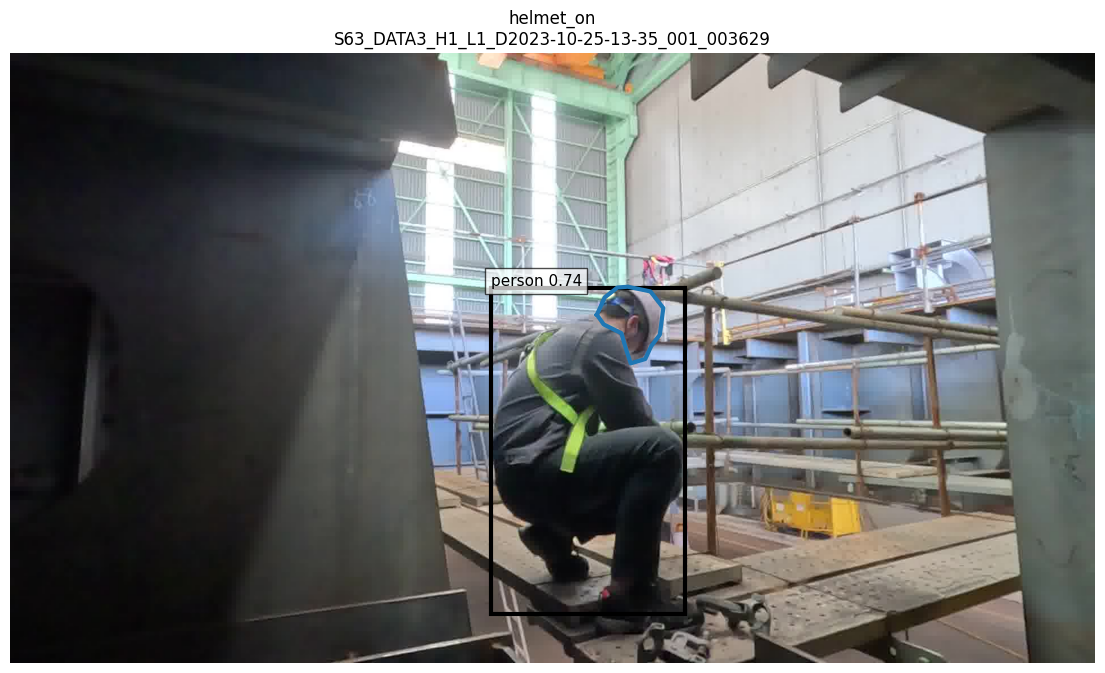

In [51]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


TRAIN_MANIFEST = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits/"
    "train_annotation_manifest.jsonl"
)


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


train_records = read_jsonl(TRAIN_MANIFEST)

sample_record = random.Random(42).choice(train_records)

sample_image_path = sample_record["image_path"]

results = person_model.predict(
    source=sample_image_path,
    classes=[0],       # COCO person
    conf=0.20,
    imgsz=1280,
    device=0,
    verbose=False,
)

result = results[0]

image_bgr = cv2.imread(sample_image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(image_rgb)

if result.boxes is not None:
    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    for box, confidence in zip(boxes, confidences):
        x1, y1, x2, y2 = box

        ax.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=3,
            )
        )

        ax.text(
            x1,
            max(y1 - 5, 0),
            f"person {confidence:.2f}",
            fontsize=11,
            bbox={"facecolor": "white", "alpha": 0.7},
        )

polygon = np.asarray(
    sample_record["polygon"],
    dtype=np.float32,
)

ax.plot(
    np.append(polygon[:, 0], polygon[0, 0]),
    np.append(polygon[:, 1], polygon[0, 1]),
    linewidth=3,
)

ax.set_title(
    f"{sample_record['class_name']}\n"
    f"{sample_record['stem']}"
)
ax.axis("off")
plt.show()

In [52]:
import math
import numpy as np


PERSON_EXPAND_RATIO = 0.15


def get_polygon_center(record):
    polygon = np.asarray(
        record["polygon"],
        dtype=np.float32,
    )

    return (
        float(polygon[:, 0].mean()),
        float(polygon[:, 1].mean()),
    )


def expand_box(box, image_width, image_height, ratio=0.15):
    x1, y1, x2, y2 = map(float, box)

    width = x2 - x1
    height = y2 - y1

    x1 -= width * ratio
    x2 += width * ratio
    y1 -= height * ratio
    y2 += height * ratio

    return [
        max(x1, 0.0),
        max(y1, 0.0),
        min(x2, float(image_width)),
        min(y2, float(image_height)),
    ]


def point_inside_box(point, box):
    x, y = point
    x1, y1, x2, y2 = box

    return (
        x1 <= x <= x2
        and y1 <= y <= y2
    )


def box_center(box):
    x1, y1, x2, y2 = box

    return (
        (x1 + x2) / 2.0,
        (y1 + y2) / 2.0,
    )


def center_distance(point, box):
    px, py = point
    bx, by = box_center(box)

    return math.hypot(px - bx, py - by)


def match_person_box(
    record,
    person_boxes,
    person_confidences,
):
    polygon_center = get_polygon_center(record)

    image_width = int(record["image_width"])
    image_height = int(record["image_height"])

    original_candidates = []

    for index, box in enumerate(person_boxes):
        box_list = box.tolist()

        if point_inside_box(
            polygon_center,
            box_list,
        ):
            original_candidates.append(index)

    if original_candidates:
        best_index = min(
            original_candidates,
            key=lambda index: center_distance(
                polygon_center,
                person_boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method": "inside_original_box",
            "person_bbox": person_boxes[best_index].tolist(),
            "person_confidence": float(
                person_confidences[best_index]
            ),
        }

    expanded_candidates = []

    for index, box in enumerate(person_boxes):
        expanded = expand_box(
            box,
            image_width,
            image_height,
            ratio=PERSON_EXPAND_RATIO,
        )

        if point_inside_box(
            polygon_center,
            expanded,
        ):
            expanded_candidates.append(index)

    if expanded_candidates:
        best_index = min(
            expanded_candidates,
            key=lambda index: center_distance(
                polygon_center,
                person_boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method": "inside_expanded_box",
            "person_bbox": person_boxes[best_index].tolist(),
            "person_confidence": float(
                person_confidences[best_index]
            ),
        }

    return {
        "matched": False,
        "match_method": "unmatched",
        "person_bbox": None,
        "person_confidence": None,
    }


print("Person-PPE matching 함수 준비 완료")

Person-PPE matching 함수 준비 완료


In [53]:
from collections import Counter
from pathlib import Path
from tqdm.auto import tqdm


MINI_ALL_MANIFEST = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits/mini/"
    "mini_all_manifest.jsonl"
)

PERSON_ROI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/person_roi"
)

PERSON_ROI_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

mini_records = read_jsonl(MINI_ALL_MANIFEST)

print("Mini annotation:", len(mini_records))

Mini annotation: 4800


In [54]:
from collections import defaultdict


records_by_image = defaultdict(list)

for record in mini_records:
    records_by_image[record["image_path"]].append(record)

unique_image_paths = list(records_by_image.keys())

print("고유 이미지:", len(unique_image_paths))

고유 이미지: 4799


In [55]:
person_results_by_image = {}

PERSON_CONFIDENCE = 0.15
PERSON_IMAGE_SIZE = 1280
PERSON_BATCH_SIZE = 8


for start_index in tqdm(
    range(0, len(unique_image_paths), PERSON_BATCH_SIZE),
    desc="Person inference",
):
    batch_paths = unique_image_paths[
        start_index:start_index + PERSON_BATCH_SIZE
    ]

    batch_results = person_model.predict(
        source=batch_paths,
        classes=[0],
        conf=PERSON_CONFIDENCE,
        imgsz=PERSON_IMAGE_SIZE,
        device=0,
        verbose=False,
    )

    for image_path, result in zip(
        batch_paths,
        batch_results,
    ):
        if result.boxes is None:
            boxes = np.empty((0, 4), dtype=np.float32)
            confidences = np.empty((0,), dtype=np.float32)
        else:
            boxes = result.boxes.xyxy.cpu().numpy()
            confidences = result.boxes.conf.cpu().numpy()

        person_results_by_image[image_path] = {
            "boxes": boxes,
            "confidences": confidences,
        }


print("Person inference 완료:", len(person_results_by_image))

Person inference:   0%|          | 0/600 [00:00<?, ?it/s]

Person inference 완료: 4799


In [56]:
person_roi_records = []
unmatched_records = []


for record in mini_records:
    detection = person_results_by_image[
        record["image_path"]
    ]

    match = match_person_box(
        record=record,
        person_boxes=detection["boxes"],
        person_confidences=detection["confidences"],
    )

    updated_record = dict(record)

    updated_record["person_matched"] = match["matched"]
    updated_record["person_match_method"] = match["match_method"]
    updated_record["person_bbox"] = match["person_bbox"]
    updated_record["person_confidence"] = match[
        "person_confidence"
    ]
    updated_record["person_detection_count"] = len(
        detection["boxes"]
    )

    if match["matched"]:
        person_roi_records.append(updated_record)
    else:
        unmatched_records.append(updated_record)


print("전체 annotation:", len(mini_records))
print("person 매칭 성공:", len(person_roi_records))
print("person 매칭 실패:", len(unmatched_records))
print(
    "매칭률:",
    f"{len(person_roi_records) / len(mini_records) * 100:.2f}%"
)

전체 annotation: 4800
person 매칭 성공: 4304
person 매칭 실패: 496
매칭률: 89.67%


In [57]:
import pandas as pd


match_rows = []

for record in mini_records:
    detection = person_results_by_image[
        record["image_path"]
    ]

    match = match_person_box(
        record,
        detection["boxes"],
        detection["confidences"],
    )

    match_rows.append({
        "class_name": record["class_name"],
        "task_id": record["task_id"],
        "matched": match["matched"],
        "match_method": match["match_method"],
        "person_detection_count": len(
            detection["boxes"]
        ),
    })


match_df = pd.DataFrame(match_rows)

class_match_summary = (
    match_df.groupby("class_name")
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
    )
    .reset_index()
)

class_match_summary["match_rate_percent"] = (
    class_match_summary["matched"]
    / class_match_summary["total"]
    * 100
)

display(class_match_summary.round(2))

print("\n매칭 방식")
display(
    match_df["match_method"]
    .value_counts()
    .rename_axis("match_method")
    .reset_index(name="count")
)

,class_name,total,matched,match_rate_percent
0,harness_off,800,783,97.88
1,harness_on,800,762,95.25
2,helmet_off,800,778,97.25
3,helmet_on,800,729,91.12
4,welding_mask_off,800,783,97.88
5,welding_mask_on,800,469,58.63



매칭 방식


,match_method,count
0,inside_original_box,4273
1,unmatched,496
2,inside_expanded_box,31


In [58]:
def write_jsonl(records, path):
    with Path(path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(record, ensure_ascii=False)
                + "\n"
            )


MATCHED_PATH = (
    PERSON_ROI_ROOT
    / "mini_person_roi_matched.jsonl"
)

UNMATCHED_PATH = (
    PERSON_ROI_ROOT
    / "mini_person_roi_unmatched.jsonl"
)

SUMMARY_PATH = (
    PERSON_ROI_ROOT
    / "mini_person_roi_match_summary.csv"
)


write_jsonl(
    person_roi_records,
    MATCHED_PATH,
)

write_jsonl(
    unmatched_records,
    UNMATCHED_PATH,
)

class_match_summary.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)


print("저장 완료")
print(MATCHED_PATH)
print(UNMATCHED_PATH)
print(SUMMARY_PATH)

저장 완료
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/mini_person_roi_matched.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/mini_person_roi_unmatched.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/mini_person_roi_match_summary.csv


In [59]:
import pandas as pd

unmatched_df = pd.DataFrame(unmatched_records)

unmatched_df["failure_type"] = unmatched_df[
    "person_detection_count"
].apply(
    lambda count: (
        "no_person_detected"
        if count == 0
        else "person_detected_but_unmatched"
    )
)

print("전체 실패 원인")
display(
    unmatched_df["failure_type"]
    .value_counts()
    .rename_axis("failure_type")
    .reset_index(name="count")
)

print("\n클래스별 실패 원인")
display(
    pd.crosstab(
        unmatched_df["class_name"],
        unmatched_df["failure_type"],
    )
)

전체 실패 원인


,failure_type,count
0,no_person_detected,326
1,person_detected_but_unmatched,170



클래스별 실패 원인


failure_type,no_person_detected,person_detected_but_unmatched
class_name,,
harness_off,12,5
harness_on,35,3
helmet_off,18,4
helmet_on,58,13
welding_mask_off,7,10
welding_mask_on,196,135


In [60]:
from collections import defaultdict
from tqdm.auto import tqdm
import numpy as np

unmatched_by_image = defaultdict(list)

for record in unmatched_records:
    unmatched_by_image[
        record["image_path"]
    ].append(record)

retry_image_paths = list(
    unmatched_by_image.keys()
)

print("재검출 대상 고유 이미지:", len(retry_image_paths))


RETRY_CONFIDENCE = 0.05
RETRY_IMAGE_SIZE = 1536
RETRY_BATCH_SIZE = 4

retry_results_by_image = {}


for start_index in tqdm(
    range(
        0,
        len(retry_image_paths),
        RETRY_BATCH_SIZE,
    ),
    desc="Unmatched person retry",
):
    batch_paths = retry_image_paths[
        start_index:
        start_index + RETRY_BATCH_SIZE
    ]

    batch_results = person_model.predict(
        source=batch_paths,
        classes=[0],
        conf=RETRY_CONFIDENCE,
        imgsz=RETRY_IMAGE_SIZE,
        device=0,
        verbose=False,
    )

    for image_path, result in zip(
        batch_paths,
        batch_results,
    ):
        if (
            result.boxes is None
            or len(result.boxes) == 0
        ):
            boxes = np.empty(
                (0, 4),
                dtype=np.float32,
            )
            confidences = np.empty(
                (0,),
                dtype=np.float32,
            )
        else:
            boxes = (
                result.boxes.xyxy
                .cpu()
                .numpy()
            )

            confidences = (
                result.boxes.conf
                .cpu()
                .numpy()
            )

        retry_results_by_image[
            image_path
        ] = {
            "boxes": boxes,
            "confidences": confidences,
        }

print(
    "재추론 완료:",
    len(retry_results_by_image),
)

재검출 대상 고유 이미지: 496


Unmatched person retry:   0%|          | 0/124 [00:00<?, ?it/s]

재추론 완료: 496


In [61]:
def match_person_box_retry(
    record,
    person_boxes,
    person_confidences,
    expand_ratio=0.30,
):
    polygon_center = get_polygon_center(
        record
    )

    image_width = int(
        record["image_width"]
    )
    image_height = int(
        record["image_height"]
    )

    # 1. 원본 bbox 내부
    original_candidates = []

    for index, box in enumerate(
        person_boxes
    ):
        box_list = box.tolist()

        if point_inside_box(
            polygon_center,
            box_list,
        ):
            original_candidates.append(
                index
            )

    if original_candidates:
        best_index = min(
            original_candidates,
            key=lambda index: center_distance(
                polygon_center,
                person_boxes[
                    index
                ].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method":
                "retry_inside_original_box",
            "person_bbox":
                person_boxes[
                    best_index
                ].tolist(),
            "person_confidence":
                float(
                    person_confidences[
                        best_index
                    ]
                ),
        }

    # 2. 확장 bbox 내부
    expanded_candidates = []

    for index, box in enumerate(
        person_boxes
    ):
        expanded_box = expand_box(
            box,
            image_width,
            image_height,
            ratio=expand_ratio,
        )

        if point_inside_box(
            polygon_center,
            expanded_box,
        ):
            expanded_candidates.append(
                index
            )

    if expanded_candidates:
        best_index = min(
            expanded_candidates,
            key=lambda index: center_distance(
                polygon_center,
                person_boxes[
                    index
                ].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method":
                "retry_inside_expanded_box",
            "person_bbox":
                person_boxes[
                    best_index
                ].tolist(),
            "person_confidence":
                float(
                    person_confidences[
                        best_index
                    ]
                ),
        }

    return {
        "matched": False,
        "match_method":
            "retry_unmatched",
        "person_bbox": None,
        "person_confidence": None,
    }

In [62]:
recovered_records = []
still_unmatched_records = []


for record in unmatched_records:
    detection = retry_results_by_image[
        record["image_path"]
    ]

    retry_match = match_person_box_retry(
        record=record,
        person_boxes=detection["boxes"],
        person_confidences=detection[
            "confidences"
        ],
        expand_ratio=0.30,
    )

    updated_record = dict(record)

    updated_record[
        "person_retry_detection_count"
    ] = len(detection["boxes"])

    updated_record[
        "person_matched"
    ] = retry_match["matched"]

    updated_record[
        "person_match_method"
    ] = retry_match["match_method"]

    updated_record[
        "person_bbox"
    ] = retry_match["person_bbox"]

    updated_record[
        "person_confidence"
    ] = retry_match[
        "person_confidence"
    ]

    if retry_match["matched"]:
        recovered_records.append(
            updated_record
        )
    else:
        still_unmatched_records.append(
            updated_record
        )


final_person_roi_records = (
    person_roi_records
    + recovered_records
)


print("기존 성공:", len(person_roi_records))
print("재시도 복구:", len(recovered_records))
print(
    "최종 성공:",
    len(final_person_roi_records),
)
print(
    "최종 실패:",
    len(still_unmatched_records),
)

print(
    "최종 매칭률:",
    f"{len(final_person_roi_records) / len(mini_records) * 100:.2f}%"
)

기존 성공: 4304
재시도 복구: 42
최종 성공: 4346
최종 실패: 454
최종 매칭률: 90.54%


In [63]:
final_match_rows = []

matched_record_ids = {
    record["record_id"]
    for record in final_person_roi_records
}


for record in mini_records:
    final_match_rows.append({
        "class_name":
            record["class_name"],

        "matched":
            record["record_id"]
            in matched_record_ids,
    })


final_match_df = pd.DataFrame(
    final_match_rows
)

final_class_summary = (
    final_match_df
    .groupby("class_name")
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
    )
    .reset_index()
)

final_class_summary[
    "match_rate_percent"
] = (
    final_class_summary["matched"]
    / final_class_summary["total"]
    * 100
)

display(
    final_class_summary.round(2)
)

,class_name,total,matched,match_rate_percent
0,harness_off,800,785,98.12
1,harness_on,800,769,96.12
2,helmet_off,800,781,97.62
3,helmet_on,800,746,93.25
4,welding_mask_off,800,786,98.25
5,welding_mask_on,800,479,59.88


In [64]:
from pathlib import Path
from ultralytics import YOLO

SHIPYARD_MODEL_PATH = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/sh_segmentation.pt"
)

assert SHIPYARD_MODEL_PATH.exists(), (
    f"모델 파일을 찾지 못했습니다: {SHIPYARD_MODEL_PATH}"
)

shipyard_person_model = YOLO(str(SHIPYARD_MODEL_PATH))

print("모델 경로:", SHIPYARD_MODEL_PATH)
print("모델 로드 완료")
print("클래스 정보:", shipyard_person_model.names)

모델 경로: /content/drive/MyDrive/YardOps_PPE_Dataset/sh_segmentation.pt
모델 로드 완료
클래스 정보: {0: '안전대미착용', 1: '안전대착용', 2: '안전모미착용', 3: '안전모착용', 4: '용접마스크미착용', 5: '용접마스크착용', 6: '지게차', 7: '고소작업차', 8: '발판비계', 9: '배관', 10: '트랜스포터', 11: '크레인', 12: '연기', 13: '용접 마스크', 14: '작업자'}


In [65]:
for class_id, class_name in shipyard_person_model.names.items():
    print(class_id, class_name)

0 안전대미착용
1 안전대착용
2 안전모미착용
3 안전모착용
4 용접마스크미착용
5 용접마스크착용
6 지게차
7 고소작업차
8 발판비계
9 배관
10 트랜스포터
11 크레인
12 연기
13 용접 마스크
14 작업자


In [66]:
SHIPYARD_PERSON_CLASS = 14

In [68]:
from pathlib import Path
from tqdm.auto import tqdm
from ultralytics import YOLO
import numpy as np

SHIPYARD_MODEL_PATH = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/sh_segmentation.pt"
)

assert SHIPYARD_MODEL_PATH.exists(), SHIPYARD_MODEL_PATH

shipyard_person_model = YOLO(str(SHIPYARD_MODEL_PATH))

print("클래스 정보:", shipyard_person_model.names)

SHIPYARD_PERSON_CLASS = 14

assert SHIPYARD_PERSON_CLASS in shipyard_person_model.names
print(
    "작업자 클래스:",
    SHIPYARD_PERSON_CLASS,
    shipyard_person_model.names[SHIPYARD_PERSON_CLASS],
)

클래스 정보: {0: '안전대미착용', 1: '안전대착용', 2: '안전모미착용', 3: '안전모착용', 4: '용접마스크미착용', 5: '용접마스크착용', 6: '지게차', 7: '고소작업차', 8: '발판비계', 9: '배관', 10: '트랜스포터', 11: '크레인', 12: '연기', 13: '용접 마스크', 14: '작업자'}
작업자 클래스: 14 작업자


In [69]:
SHIPYARD_CONFIDENCE = 0.15
SHIPYARD_IMAGE_SIZE = 1280
SHIPYARD_BATCH_SIZE = 8

shipyard_results_all = {}

for start_index in tqdm(
    range(0, len(unique_image_paths), SHIPYARD_BATCH_SIZE),
    desc="Shipyard model full inference",
):
    batch_paths = unique_image_paths[
        start_index:start_index + SHIPYARD_BATCH_SIZE
    ]

    batch_results = shipyard_person_model.predict(
        source=batch_paths,
        classes=[SHIPYARD_PERSON_CLASS],
        conf=SHIPYARD_CONFIDENCE,
        imgsz=SHIPYARD_IMAGE_SIZE,
        device=0,
        verbose=False,
    )

    for image_path, result in zip(batch_paths, batch_results):
        if result.boxes is None or len(result.boxes) == 0:
            boxes = np.empty((0, 4), dtype=np.float32)
            confidences = np.empty((0,), dtype=np.float32)
        else:
            boxes = result.boxes.xyxy.cpu().numpy()
            confidences = result.boxes.conf.cpu().numpy()

        shipyard_results_all[image_path] = {
            "boxes": boxes,
            "confidences": confidences,
        }

print("전체 추론 이미지:", len(shipyard_results_all))

Shipyard model full inference:   0%|          | 0/600 [00:00<?, ?it/s]

전체 추론 이미지: 4799


In [70]:
import pandas as pd


def evaluate_person_matcher(
    records,
    detections_by_image,
    model_name,
):
    rows = []
    matched_records = []
    unmatched_records_local = []

    for record in records:
        detection = detections_by_image[
            record["image_path"]
        ]

        match = match_person_box(
            record=record,
            person_boxes=detection["boxes"],
            person_confidences=detection["confidences"],
        )

        updated = dict(record)
        updated["person_matched"] = match["matched"]
        updated["person_match_method"] = match["match_method"]
        updated["person_bbox"] = match["person_bbox"]
        updated["person_confidence"] = match["person_confidence"]
        updated["person_detection_count"] = len(
            detection["boxes"]
        )
        updated["person_model_source"] = model_name

        if match["matched"]:
            matched_records.append(updated)
        else:
            unmatched_records_local.append(updated)

        rows.append({
            "record_id": record["record_id"],
            "class_name": record["class_name"],
            "task_id": record["task_id"],
            "model_name": model_name,
            "matched": match["matched"],
            "match_method": match["match_method"],
            "person_detection_count": len(
                detection["boxes"]
            ),
            "person_confidence": match["person_confidence"],
        })

    return (
        pd.DataFrame(rows),
        matched_records,
        unmatched_records_local,
    )

In [71]:
coco_eval_df, coco_matched, coco_unmatched = (
    evaluate_person_matcher(
        records=mini_records,
        detections_by_image=person_results_by_image,
        model_name="coco_person",
    )
)

shipyard_eval_df, shipyard_matched, shipyard_unmatched = (
    evaluate_person_matcher(
        records=mini_records,
        detections_by_image=shipyard_results_all,
        model_name="shipyard_person",
    )
)

comparison_df = pd.concat(
    [coco_eval_df, shipyard_eval_df],
    ignore_index=True,
)

print("COCO 매칭률:")
print(coco_eval_df["matched"].mean() * 100)

print("\n조선소 모델 매칭률:")
print(shipyard_eval_df["matched"].mean() * 100)

COCO 매칭률:
89.66666666666666

조선소 모델 매칭률:
7.104166666666667


In [72]:
pair_comparison = (
    coco_eval_df[
        ["record_id", "class_name", "matched"]
    ]
    .rename(columns={"matched": "coco_matched"})
    .merge(
        shipyard_eval_df[
            ["record_id", "matched"]
        ].rename(
            columns={"matched": "shipyard_matched"}
        ),
        on="record_id",
        how="inner",
    )
)

pair_comparison["comparison_type"] = np.select(
    [
        pair_comparison["coco_matched"]
        & pair_comparison["shipyard_matched"],

        pair_comparison["coco_matched"]
        & ~pair_comparison["shipyard_matched"],

        ~pair_comparison["coco_matched"]
        & pair_comparison["shipyard_matched"],
    ],
    [
        "both_matched",
        "coco_only",
        "shipyard_only",
    ],
    default="both_failed",
)

print("전체 성공 관계")

display(
    pair_comparison["comparison_type"]
    .value_counts()
    .rename_axis("comparison_type")
    .reset_index(name="count")
)

print("\n클래스별 성공 관계")

display(
    pd.crosstab(
        pair_comparison["class_name"],
        pair_comparison["comparison_type"],
    )
)

전체 성공 관계


,comparison_type,count
0,coco_only,4116
1,both_failed,343
2,both_matched,188
3,shipyard_only,153



클래스별 성공 관계


comparison_type,both_failed,both_matched,coco_only,shipyard_only
class_name,,,,
harness_off,17,2,781,0
harness_on,38,0,762,0
helmet_off,22,1,777,0
helmet_on,71,5,724,0
welding_mask_off,17,0,783,0
welding_mask_on,178,180,289,153


In [73]:
hybrid_results_by_image = {}

for image_path in unique_image_paths:
    coco_detection = person_results_by_image[image_path]
    shipyard_detection = shipyard_results_all[image_path]

    coco_boxes = coco_detection["boxes"]
    shipyard_boxes = shipyard_detection["boxes"]

    coco_confidences = coco_detection["confidences"]
    shipyard_confidences = shipyard_detection["confidences"]

    if len(coco_boxes) == 0 and len(shipyard_boxes) == 0:
        combined_boxes = np.empty(
            (0, 4),
            dtype=np.float32,
        )
        combined_confidences = np.empty(
            (0,),
            dtype=np.float32,
        )

    elif len(coco_boxes) == 0:
        combined_boxes = shipyard_boxes.copy()
        combined_confidences = shipyard_confidences.copy()

    elif len(shipyard_boxes) == 0:
        combined_boxes = coco_boxes.copy()
        combined_confidences = coco_confidences.copy()

    else:
        combined_boxes = np.concatenate(
            [coco_boxes, shipyard_boxes],
            axis=0,
        )

        combined_confidences = np.concatenate(
            [
                coco_confidences,
                shipyard_confidences,
            ],
            axis=0,
        )

    hybrid_results_by_image[image_path] = {
        "boxes": combined_boxes,
        "confidences": combined_confidences,
    }

In [74]:
hybrid_eval_df, hybrid_matched, hybrid_unmatched = (
    evaluate_person_matcher(
        records=mini_records,
        detections_by_image=hybrid_results_by_image,
        model_name="hybrid",
    )
)

all_model_comparison = pd.concat(
    [
        coco_eval_df,
        shipyard_eval_df,
        hybrid_eval_df,
    ],
    ignore_index=True,
)

final_summary = (
    all_model_comparison
    .groupby(["model_name", "class_name"])
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
    )
    .reset_index()
)

final_summary["match_rate_percent"] = (
    final_summary["matched"]
    / final_summary["total"]
    * 100
)

print("모델별 전체 매칭률")

display(
    all_model_comparison
    .groupby("model_name")["matched"]
    .mean()
    .mul(100)
    .round(2)
    .rename("match_rate_percent")
    .reset_index()
)

print("\n모델별 클래스 매칭률")

display(
    final_summary
    .pivot(
        index="class_name",
        columns="model_name",
        values="match_rate_percent",
    )
    .round(2)
)

모델별 전체 매칭률


,model_name,match_rate_percent
0,coco_person,89.67
1,hybrid,92.85
2,shipyard_person,7.10



모델별 클래스 매칭률


model_name,coco_person,hybrid,shipyard_person
class_name,,,
harness_off,97.88,97.88,0.25
harness_on,95.25,95.25,0.00
helmet_off,97.25,97.25,0.12
helmet_on,91.12,91.12,0.62
welding_mask_off,97.88,97.88,0.00
welding_mask_on,58.63,77.75,41.62


In [75]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


shipyard_only_ids = set(
    pair_comparison.loc[
        pair_comparison["comparison_type"] == "shipyard_only",
        "record_id",
    ]
)

shipyard_only_records = [
    record
    for record in shipyard_matched
    if record["record_id"] in shipyard_only_ids
]

print("Shipyard-only records:", len(shipyard_only_records))


def visualize_person_match(record):
    image = cv2.imread(record["image_path"])

    if image is None:
        raise FileNotFoundError(record["image_path"])

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    polygon = np.asarray(
        record["polygon"],
        dtype=np.float32,
    )

    person_bbox = record["person_bbox"]

    fig, ax = plt.subplots(figsize=(13, 8))
    ax.imshow(image)

    # PPE polygon
    closed_polygon = np.vstack(
        [polygon, polygon[0]]
    )

    ax.plot(
        closed_polygon[:, 0],
        closed_polygon[:, 1],
        linewidth=3,
        label="PPE polygon",
    )

    # 작업자 bbox
    x1, y1, x2, y2 = person_bbox

    ax.add_patch(
        Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=3,
        )
    )

    ax.set_title(
        f"{record['class_name']}\n"
        f"confidence={record['person_confidence']:.3f}\n"
        f"{record['stem']}"
    )

    ax.axis("off")
    plt.show()


random.seed(42)

selected_records = random.sample(
    shipyard_only_records,
    k=min(20, len(shipyard_only_records)),
)

for record in selected_records:
    visualize_person_match(record)

Output hidden; open in https://colab.research.google.com to view.

In [76]:
def build_hybrid_detections_with_source(
    image_path,
):
    coco_detection = person_results_by_image[
        image_path
    ]

    shipyard_detection = shipyard_results_all[
        image_path
    ]

    boxes = []
    confidences = []
    sources = []

    for box, confidence in zip(
        coco_detection["boxes"],
        coco_detection["confidences"],
    ):
        boxes.append(box)
        confidences.append(confidence)
        sources.append("coco_person")

    for box, confidence in zip(
        shipyard_detection["boxes"],
        shipyard_detection["confidences"],
    ):
        boxes.append(box)
        confidences.append(confidence)
        sources.append("shipyard_person")

    if not boxes:
        return {
            "boxes": np.empty(
                (0, 4),
                dtype=np.float32,
            ),
            "confidences": np.empty(
                (0,),
                dtype=np.float32,
            ),
            "sources": [],
        }

    return {
        "boxes": np.asarray(
            boxes,
            dtype=np.float32,
        ),
        "confidences": np.asarray(
            confidences,
            dtype=np.float32,
        ),
        "sources": sources,
    }

In [77]:
def match_person_box_with_source(
    record,
    detection,
    expand_ratio=0.15,
):
    boxes = detection["boxes"]
    confidences = detection["confidences"]
    sources = detection["sources"]

    polygon_center = get_polygon_center(record)

    width = int(record["image_width"])
    height = int(record["image_height"])

    original_candidates = []

    for index, box in enumerate(boxes):
        if point_inside_box(
            polygon_center,
            box.tolist(),
        ):
            original_candidates.append(index)

    if original_candidates:
        best_index = min(
            original_candidates,
            key=lambda index: center_distance(
                polygon_center,
                boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method": "inside_original_box",
            "person_bbox": boxes[
                best_index
            ].tolist(),
            "person_confidence": float(
                confidences[best_index]
            ),
            "person_model_source": sources[
                best_index
            ],
        }

    expanded_candidates = []

    for index, box in enumerate(boxes):
        expanded = expand_box(
            box,
            width,
            height,
            ratio=expand_ratio,
        )

        if point_inside_box(
            polygon_center,
            expanded,
        ):
            expanded_candidates.append(index)

    if expanded_candidates:
        best_index = min(
            expanded_candidates,
            key=lambda index: center_distance(
                polygon_center,
                boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method": "inside_expanded_box",
            "person_bbox": boxes[
                best_index
            ].tolist(),
            "person_confidence": float(
                confidences[best_index]
            ),
            "person_model_source": sources[
                best_index
            ],
        }

    return {
        "matched": False,
        "match_method": "unmatched",
        "person_bbox": None,
        "person_confidence": None,
        "person_model_source": None,
    }

In [78]:
hybrid_person_roi_records = []
hybrid_unmatched_records = []

for record in mini_records:
    detection = build_hybrid_detections_with_source(
        record["image_path"]
    )

    match = match_person_box_with_source(
        record=record,
        detection=detection,
        expand_ratio=0.15,
    )

    updated = dict(record)

    updated["person_matched"] = match["matched"]
    updated["person_match_method"] = match[
        "match_method"
    ]
    updated["person_bbox"] = match["person_bbox"]
    updated["person_confidence"] = match[
        "person_confidence"
    ]
    updated["person_model_source"] = match[
        "person_model_source"
    ]
    updated["person_detection_count"] = len(
        detection["boxes"]
    )

    if match["matched"]:
        hybrid_person_roi_records.append(updated)
    else:
        hybrid_unmatched_records.append(updated)


print(
    "Hybrid matched:",
    len(hybrid_person_roi_records),
)

print(
    "Hybrid unmatched:",
    len(hybrid_unmatched_records),
)

print(
    "Hybrid match rate:",
    f"{len(hybrid_person_roi_records) / len(mini_records) * 100:.2f}%"
)

Hybrid matched: 4457
Hybrid unmatched: 343
Hybrid match rate: 92.85%


In [79]:
from pathlib import Path
import json
import pandas as pd


PERSON_ROI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/person_roi"
)

PERSON_ROI_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def write_jsonl(records, path):
    with Path(path).open(
        "w",
        encoding="utf-8",
    ) as file:
        for record in records:
            file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                )
                + "\n"
            )


HYBRID_MATCHED_PATH = (
    PERSON_ROI_ROOT
    / "mini_hybrid_person_roi_matched.jsonl"
)

HYBRID_UNMATCHED_PATH = (
    PERSON_ROI_ROOT
    / "mini_hybrid_person_roi_unmatched.jsonl"
)

write_jsonl(
    hybrid_person_roi_records,
    HYBRID_MATCHED_PATH,
)

write_jsonl(
    hybrid_unmatched_records,
    HYBRID_UNMATCHED_PATH,
)


source_summary = (
    pd.DataFrame(
        hybrid_person_roi_records
    )
    .groupby(
        [
            "class_name",
            "person_model_source",
        ]
    )
    .size()
    .reset_index(name="count")
)

display(source_summary)

print(HYBRID_MATCHED_PATH)
print(HYBRID_UNMATCHED_PATH)

,class_name,person_model_source,count
0,harness_off,coco_person,782
1,harness_off,shipyard_person,1
2,harness_on,coco_person,762
3,helmet_off,coco_person,777
4,helmet_off,shipyard_person,1
5,helmet_on,coco_person,725
6,helmet_on,shipyard_person,4
7,welding_mask_off,coco_person,783
8,welding_mask_on,coco_person,402
9,welding_mask_on,shipyard_person,220


/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/mini_hybrid_person_roi_matched.jsonl
/content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/mini_hybrid_person_roi_unmatched.jsonl


In [80]:
import json
from pathlib import Path
from collections import Counter

PERSON_ROI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/person_roi"
)
PERSON_ROI_ROOT.mkdir(parents=True, exist_ok=True)


def write_jsonl(records, path):
    with Path(path).open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")


records_by_split = {
    "train": [],
    "val": [],
    "test": [],
}

for record in hybrid_person_roi_records:
    split = record["new_split"]
    records_by_split[split].append(record)

for split, records in records_by_split.items():
    output_path = PERSON_ROI_ROOT / f"mini_hybrid_{split}.jsonl"
    write_jsonl(records, output_path)

    print(
        split,
        f"annotations={len(records):,}",
        f"images={len({r['stem'] for r in records}):,}",
    )

print("\n클래스 분포")

for split, records in records_by_split.items():
    print(f"\n[{split}]")
    print(Counter(record["class_name"] for record in records))

train annotations=2,765 images=2,765
val annotations=886 images=886
test annotations=806 images=806

클래스 분포

[train]
Counter({'harness_off': 494, 'helmet_off': 483, 'welding_mask_off': 483, 'harness_on': 467, 'helmet_on': 456, 'welding_mask_on': 382})

[val]
Counter({'helmet_on': 150, 'welding_mask_off': 150, 'welding_mask_on': 150, 'harness_off': 146, 'harness_on': 145, 'helmet_off': 145})

[test]
Counter({'welding_mask_off': 150, 'helmet_off': 150, 'harness_on': 150, 'harness_off': 143, 'helmet_on': 123, 'welding_mask_on': 90})


In [81]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF


IMAGE_SIZE = 512

TASK_TO_INDEX = {
    "helmet": 0,
    "harness": 1,
    "welding_mask": 2,
}

INDEX_TO_TASK = {
    value: key
    for key, value in TASK_TO_INDEX.items()
}


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    return records


class PPEPersonROIDataset(Dataset):
    def __init__(
        self,
        manifest_path,
        image_size=512,
        augment=False,
    ):
        self.records = read_jsonl(manifest_path)
        self.image_size = image_size
        self.augment = augment

        if not self.records:
            raise ValueError(f"빈 manifest: {manifest_path}")

    def __len__(self):
        return len(self.records)

    def _make_full_mask(self, record):
        height = int(record["image_height"])
        width = int(record["image_width"])

        mask = np.zeros((height, width), dtype=np.uint8)

        polygon = np.asarray(
            record["polygon"],
            dtype=np.float32,
        )
        polygon = np.round(polygon).astype(np.int32)

        cv2.fillPoly(mask, [polygon], color=1)

        return mask

    def _expand_person_box(
        self,
        bbox,
        image_width,
        image_height,
    ):
        x1, y1, x2, y2 = map(float, bbox)

        width = max(x2 - x1, 1.0)
        height = max(y2 - y1, 1.0)

        if self.augment:
            horizontal_ratio = np.random.uniform(0.12, 0.25)
            top_ratio = np.random.uniform(0.15, 0.30)
            bottom_ratio = np.random.uniform(0.08, 0.18)

            shift_x = np.random.uniform(-0.05, 0.05) * width
            shift_y = np.random.uniform(-0.04, 0.04) * height
        else:
            horizontal_ratio = 0.18
            top_ratio = 0.22
            bottom_ratio = 0.12
            shift_x = 0.0
            shift_y = 0.0

        x1 = x1 - width * horizontal_ratio + shift_x
        x2 = x2 + width * horizontal_ratio + shift_x
        y1 = y1 - height * top_ratio + shift_y
        y2 = y2 + height * bottom_ratio + shift_y

        x1 = max(int(round(x1)), 0)
        y1 = max(int(round(y1)), 0)
        x2 = min(int(round(x2)), image_width)
        y2 = min(int(round(y2)), image_height)

        return x1, y1, x2, y2

    def _augment_image(self, image, mask):
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[:, ::-1])
            mask = np.ascontiguousarray(mask[:, ::-1])

        if np.random.rand() < 0.5:
            factor = np.random.uniform(0.8, 1.2)
            image = np.clip(
                image.astype(np.float32) * factor,
                0,
                255,
            ).astype(np.uint8)

        return image, mask

    def __getitem__(self, index):
        record = self.records[index]

        image_bgr = cv2.imread(record["image_path"])

        if image_bgr is None:
            raise FileNotFoundError(record["image_path"])

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        full_mask = self._make_full_mask(record)

        image_height, image_width = image_rgb.shape[:2]

        x1, y1, x2, y2 = self._expand_person_box(
            record["person_bbox"],
            image_width,
            image_height,
        )

        if x2 <= x1 or y2 <= y1:
            raise ValueError(
                f"잘못된 person bbox: {record['record_id']}"
            )

        roi_image = image_rgb[y1:y2, x1:x2]
        roi_mask = full_mask[y1:y2, x1:x2]

        roi_image = cv2.resize(
            roi_image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        roi_mask = cv2.resize(
            roi_mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST,
        )

        if self.augment:
            roi_image, roi_mask = self._augment_image(
                roi_image,
                roi_mask,
            )

        image_tensor = (
            torch.from_numpy(roi_image.copy())
            .permute(2, 0, 1)
            .float()
            / 255.0
        )

        image_tensor = TF.normalize(
            image_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        mask_tensor = (
            torch.from_numpy(roi_mask.copy())
            .float()
            .unsqueeze(0)
        )
        mask_tensor = (mask_tensor > 0.5).float()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "task_index": torch.tensor(
                TASK_TO_INDEX[record["task_id"]],
                dtype=torch.long,
            ),
            "status_label": torch.tensor(
                int(record["status_label"]),
                dtype=torch.long,
            ),
            "class_name": record["class_name"],
            "task_id": record["task_id"],
            "stem": record["stem"],
            "record_id": record["record_id"],
            "person_model_source": record["person_model_source"],
            "person_bbox": torch.tensor(
                record["person_bbox"],
                dtype=torch.float32,
            ),
        }

In [82]:
TRAIN_PERSON_MANIFEST = (
    PERSON_ROI_ROOT / "mini_hybrid_train.jsonl"
)
VAL_PERSON_MANIFEST = (
    PERSON_ROI_ROOT / "mini_hybrid_val.jsonl"
)
TEST_PERSON_MANIFEST = (
    PERSON_ROI_ROOT / "mini_hybrid_test.jsonl"
)

person_train_dataset = PPEPersonROIDataset(
    TRAIN_PERSON_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=True,
)

person_val_dataset = PPEPersonROIDataset(
    VAL_PERSON_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

person_test_dataset = PPEPersonROIDataset(
    TEST_PERSON_MANIFEST,
    image_size=IMAGE_SIZE,
    augment=False,
)

BATCH_SIZE = 8

person_train_loader = DataLoader(
    person_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

person_val_loader = DataLoader(
    person_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

person_test_loader = DataLoader(
    person_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

print("Train:", len(person_train_dataset))
print("Val:", len(person_val_dataset))
print("Test:", len(person_test_dataset))

batch = next(iter(person_train_loader))

print("image:", batch["image"].shape)
print("mask:", batch["mask"].shape)
print("task:", batch["task_index"].shape)

Train: 2765
Val: 886
Test: 806
image: torch.Size([8, 3, 512, 512])
mask: torch.Size([8, 1, 512, 512])
task: torch.Size([8])


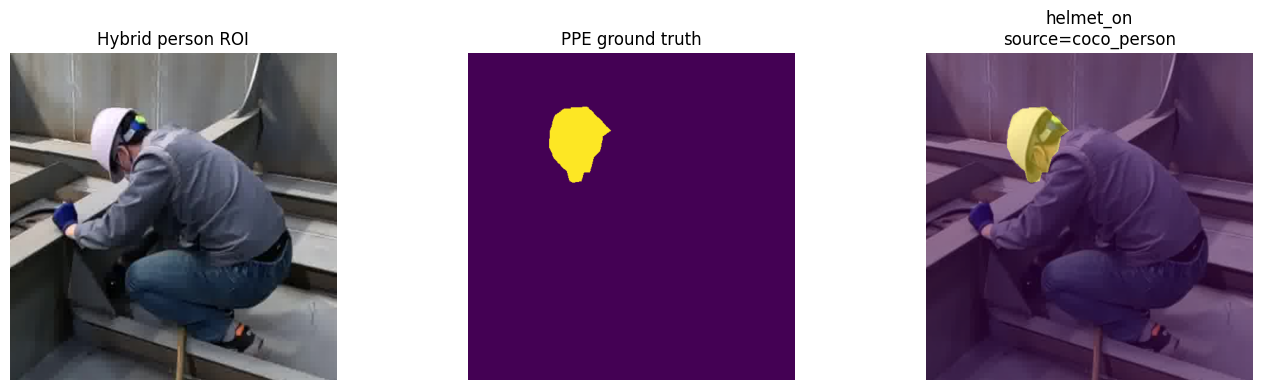

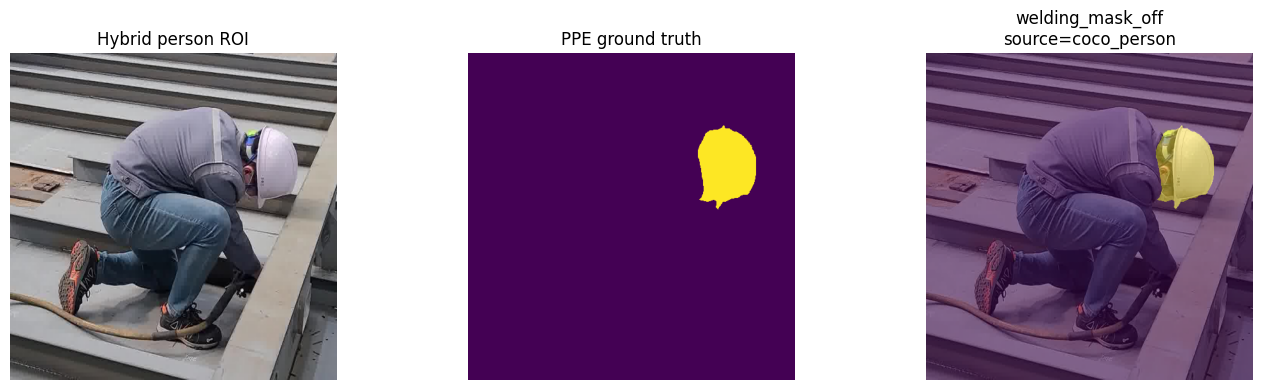

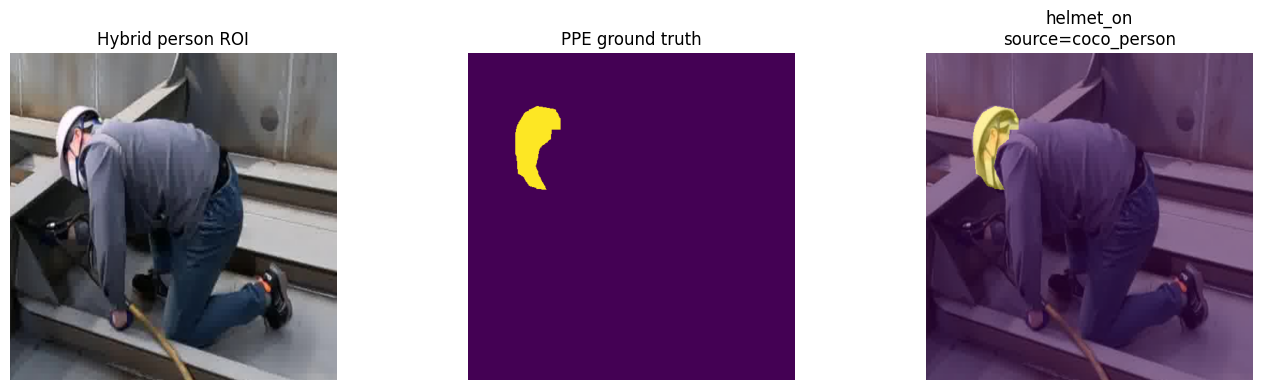

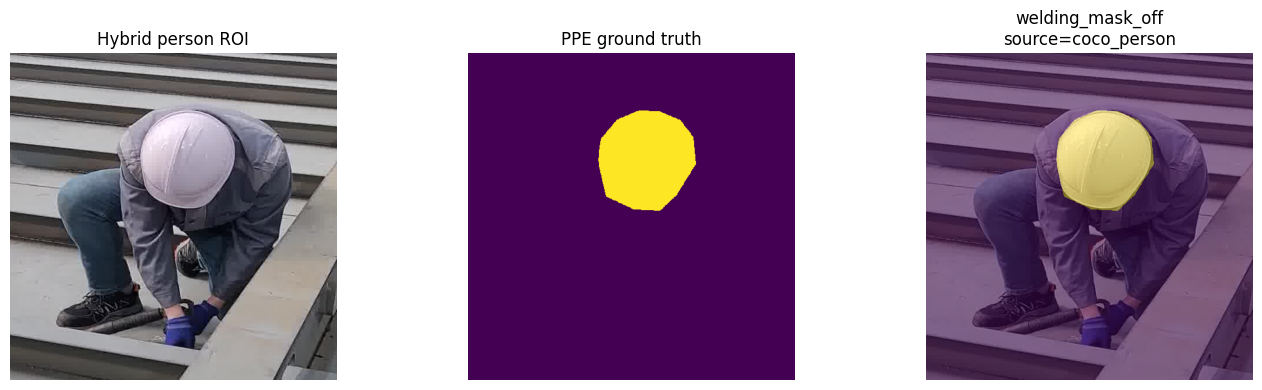

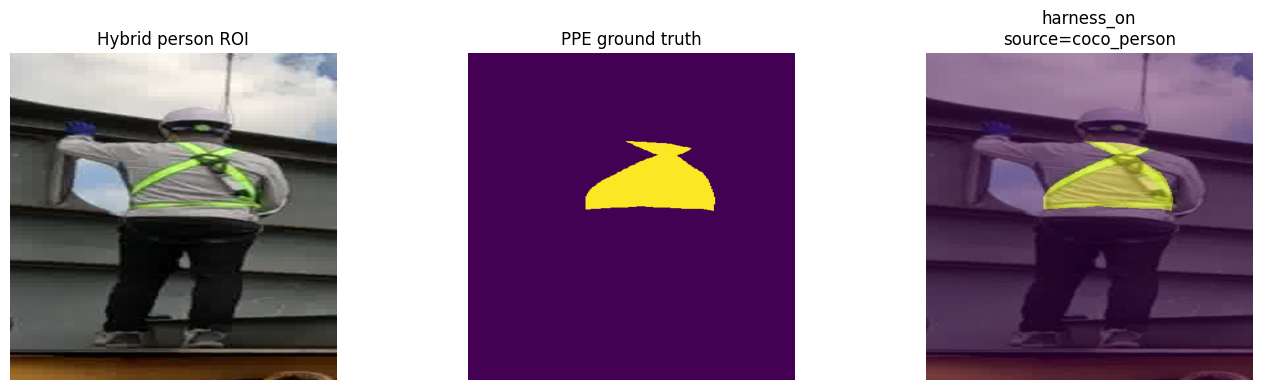

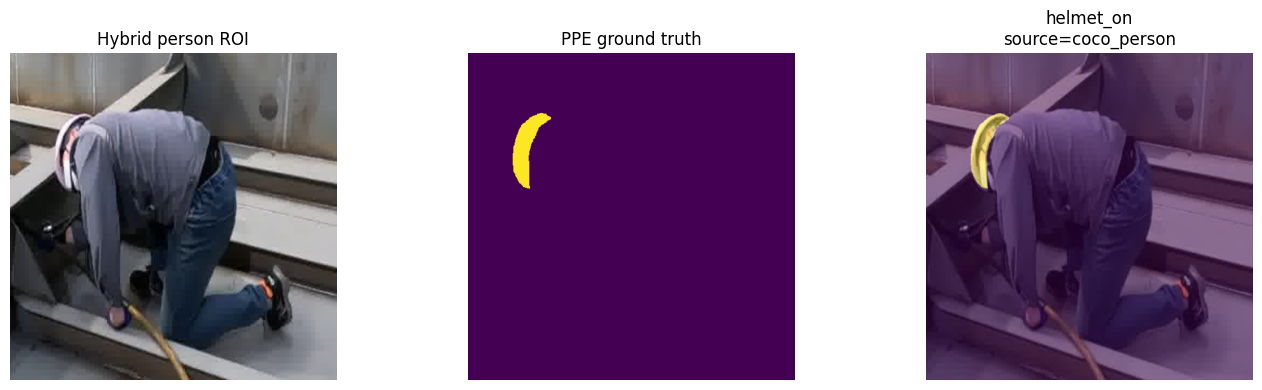

In [83]:
import matplotlib.pyplot as plt


batch = next(iter(person_val_loader))

sample_count = min(6, batch["image"].shape[0])

for index in range(sample_count):
    image = denormalize_image(
        batch["image"][index]
    )

    mask = batch["mask"][index, 0].numpy()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 4),
    )

    axes[0].imshow(image)
    axes[0].set_title("Hybrid person ROI")

    axes[1].imshow(mask)
    axes[1].set_title("PPE ground truth")

    axes[2].imshow(image)
    axes[2].imshow(mask, alpha=0.45)
    axes[2].set_title(
        f"{batch['class_name'][index]}\n"
        f"source={batch['person_model_source'][index]}"
    )

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

In [84]:
import time
from pathlib import Path

import pandas as pd
import torch


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert device.type == "cuda", "GPU 런타임을 확인하세요."


person_roi_model = SharedBackbonePPEModel(
    fpn_channels=128,
    pretrained=True,
).to(device)


PERSON_ROI_CHECKPOINT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/checkpoints/"
    "mini_hybrid_person_roi"
)

PERSON_ROI_CHECKPOINT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


person_roi_optimizer = torch.optim.AdamW(
    person_roi_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

person_roi_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        person_roi_optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )
)

person_roi_scaler = torch.amp.GradScaler(
    device.type,
    enabled=True,
)

person_roi_history = []
person_roi_best_val_loss = float("inf")


print("GPU:", torch.cuda.get_device_name(0))
print("Device:", device)
print("Train samples:", len(person_train_dataset))
print("Val samples:", len(person_val_dataset))
print("Batch size:", BATCH_SIZE)
print("Checkpoint:", PERSON_ROI_CHECKPOINT_ROOT)

GPU: NVIDIA A100-SXM4-80GB
Device: cuda
Train samples: 2765
Val samples: 886
Batch size: 8
Checkpoint: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/checkpoints/mini_hybrid_person_roi


In [85]:
training_start_time = time.time()


for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    print("\n" + "=" * 80)
    print(f"Hybrid Person ROI Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    train_metrics = train_one_epoch(
        model=person_roi_model,
        loader=person_train_loader,
        optimizer=person_roi_optimizer,
        device=device,
        scaler=person_roi_scaler,
    )

    val_metrics = validate_one_epoch(
        model=person_roi_model,
        loader=person_val_loader,
        device=device,
    )

    person_roi_scheduler.step(
        val_metrics["loss"]
    )

    current_lr = (
        person_roi_optimizer
        .param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_row = {
        "epoch": epoch,
        "learning_rate": current_lr,

        "train_loss": train_metrics["loss"],
        "train_seg_loss": train_metrics["seg_loss"],
        "train_cls_loss": train_metrics["cls_loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_accuracy": train_metrics["accuracy"],

        "val_loss": val_metrics["loss"],
        "val_seg_loss": val_metrics["seg_loss"],
        "val_cls_loss": val_metrics["cls_loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_accuracy": val_metrics["accuracy"],

        "epoch_seconds": epoch_seconds,
    }

    person_roi_history.append(history_row)

    print(
        f"Train | "
        f"loss={train_metrics['loss']:.4f}, "
        f"dice={train_metrics['dice']:.4f}, "
        f"iou={train_metrics['iou']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   | "
        f"loss={val_metrics['loss']:.4f}, "
        f"dice={val_metrics['dice']:.4f}, "
        f"iou={val_metrics['iou']:.4f}, "
        f"acc={val_metrics['accuracy']:.4f}"
    )

    print(
        f"LR={current_lr:.2e} | "
        f"시간={epoch_seconds / 60:.2f}분"
    )

    checkpoint = {
        "epoch": epoch,

        "model_state_dict":
            person_roi_model.state_dict(),

        "optimizer_state_dict":
            person_roi_optimizer.state_dict(),

        "scheduler_state_dict":
            person_roi_scheduler.state_dict(),

        "scaler_state_dict":
            person_roi_scaler.state_dict(),

        "history": person_roi_history,
        "task_to_index": TASK_TO_INDEX,
        "image_size": IMAGE_SIZE,

        "input_mode": "hybrid_person_roi",
        "person_models": [
            "coco_person",
            "sh_segmentation",
        ],
    }

    torch.save(
        checkpoint,
        PERSON_ROI_CHECKPOINT_ROOT
        / f"epoch_{epoch:02d}.pt",
    )

    if val_metrics["loss"] < person_roi_best_val_loss:
        person_roi_best_val_loss = (
            val_metrics["loss"]
        )

        checkpoint[
            "best_validation_loss"
        ] = person_roi_best_val_loss

        torch.save(
            checkpoint,
            PERSON_ROI_CHECKPOINT_ROOT
            / "best_model.pt",
        )

        print(
            "Best model 저장:",
            f"val_loss={person_roi_best_val_loss:.4f}",
        )


total_training_time = (
    time.time() - training_start_time
)

person_roi_history_df = pd.DataFrame(
    person_roi_history
)

person_roi_history_df.to_csv(
    PERSON_ROI_CHECKPOINT_ROOT
    / "training_history.csv",
    index=False,
    encoding="utf-8-sig",
)


print("\n" + "=" * 80)
print("Hybrid person ROI mini 학습 완료")
print("=" * 80)

print(
    f"전체 학습 시간: "
    f"{total_training_time / 60:.2f}분"
)

display(person_roi_history_df)


Hybrid Person ROI Epoch 1/5


Train:   0%|          | 0/346 [00:00<?, ?it/s]

Validation:   0%|          | 0/111 [00:00<?, ?it/s]

Train | loss=0.9502, dice=0.6943, iou=0.5724, acc=0.9425
Val   | loss=1.0954, dice=0.5640, iou=0.4606, acc=0.8916
LR=1.00e-04 | 시간=0.65분
Best model 저장: val_loss=1.0954

Hybrid Person ROI Epoch 2/5


Train:   0%|          | 0/346 [00:00<?, ?it/s]

...

Train | loss=0.2359, dice=0.8874, iou=0.8086, acc=0.9989
Val   | loss=0.7861, dice=0.7112, iou=0.6073, acc=0.8871
LR=1.00e-04 | 시간=0.63분

Hybrid Person ROI Epoch 5/5


Train:   0%|          | 0/346 [00:00<?, ?it/s]

Validation:   0%|          | 0/111 [00:00<?, ?it/s]

Train | loss=0.1883, dice=0.9015, iou=0.8290, acc=0.9989
Val   | loss=0.6754, dice=0.6812, iou=0.5775, acc=0.9549
LR=1.00e-04 | 시간=0.62분
Best model 저장: val_loss=0.6754

Hybrid person ROI mini 학습 완료
전체 학습 시간: 3.22분


,epoch,learning_rate,train_loss,train_seg_loss,train_cls_loss,train_dice,train_iou,train_accuracy,val_loss,val_seg_loss,val_cls_loss,val_dice,val_iou,val_accuracy,epoch_seconds
0,1,0.0001,0.950213,0.785370,0.164843,0.694306,0.572421,0.942495,1.095447,0.902453,0.192993,0.563990,0.460554,0.891648,38.712271
1,2,0.0001,0.449957,0.430953,0.019004,0.835431,0.735559,0.996383,0.889149,0.719974,0.169176,0.644764,0.543060,0.910835,37.910959
2,3,0.0001,0.315469,0.305450,0.010019,0.867684,0.779653,0.998915,0.782569,0.599327,0.183242,0.764696,0.653234,0.904063,38.008348
3,4,0.0001,0.235880,0.227147,0.008733,0.887385,0.808649,0.998915,0.786052,0.586171,0.199881,0.711165,0.607277,0.887133,37.873489
4,5,0.0001,0.188264,0.183275,0.004989,0.901541,0.828954,0.998915,0.675391,0.587653,0.087738,0.681227,0.577502,0.954853,37.491525


In [86]:
best_checkpoint = torch.load(
    PERSON_ROI_CHECKPOINT_ROOT
    / "best_model.pt",
    map_location=device,
)

person_roi_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

person_roi_model.eval()


print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best validation loss:",
    best_checkpoint["best_validation_loss"],
)


person_roi_class_results = evaluate_by_class(
    model=person_roi_model,
    loader=person_val_loader,
    device=device,
)

display(
    person_roi_class_results.round(4)
)


person_roi_class_results.to_csv(
    PERSON_ROI_CHECKPOINT_ROOT
    / "validation_class_results.csv",
    index=False,
    encoding="utf-8-sig",
)

Best epoch: 5
Best validation loss: 0.6753909065648243


Class evaluation:   0%|          | 0/111 [00:00<?, ?it/s]

,class_name,sample_count,dice,iou,status_accuracy,tp,tn,fp,fn
0,harness_off,146,0.8837,0.7982,1.0000,0,146,0,0
1,harness_on,145,0.7358,0.5990,1.0000,145,0,0,0
2,helmet_off,145,0.5182,0.3747,0.7241,0,105,40,0
3,helmet_on,150,0.1899,0.1070,1.0000,150,0,0,0
4,welding_mask_off,150,0.9251,0.8635,1.0000,0,150,0,0
5,welding_mask_on,150,0.8358,0.7219,1.0000,150,0,0,0


In [87]:
comparison_rows = [
    {
        "input_method": "full_image",
        "class_name": "harness_off",
        "dice": 0.7014,
    },
    {
        "input_method": "full_image",
        "class_name": "harness_on",
        "dice": 0.6669,
    },
    {
        "input_method": "full_image",
        "class_name": "helmet_off",
        "dice": 0.0427,
    },
    {
        "input_method": "full_image",
        "class_name": "helmet_on",
        "dice": 0.0251,
    },
    {
        "input_method": "full_image",
        "class_name": "welding_mask_off",
        "dice": 0.9093,
    },
    {
        "input_method": "full_image",
        "class_name": "welding_mask_on",
        "dice": 0.5565,
    },

    {
        "input_method": "polygon_roi",
        "class_name": "harness_off",
        "dice": 0.8314,
    },
    {
        "input_method": "polygon_roi",
        "class_name": "harness_on",
        "dice": 0.7255,
    },
    {
        "input_method": "polygon_roi",
        "class_name": "helmet_off",
        "dice": 0.4459,
    },
    {
        "input_method": "polygon_roi",
        "class_name": "helmet_on",
        "dice": 0.1043,
    },
    {
        "input_method": "polygon_roi",
        "class_name": "welding_mask_off",
        "dice": 0.9178,
    },
    {
        "input_method": "polygon_roi",
        "class_name": "welding_mask_on",
        "dice": 0.3713,
    },
]


for _, row in person_roi_class_results.iterrows():
    comparison_rows.append({
        "input_method": "hybrid_person_roi",
        "class_name": str(row["class_name"]),
        "dice": float(row["dice"]),
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

dice_comparison = comparison_df.pivot(
    index="class_name",
    columns="input_method",
    values="dice",
)

class_order = [
    "harness_off",
    "harness_on",
    "helmet_off",
    "helmet_on",
    "welding_mask_off",
    "welding_mask_on",
]

dice_comparison = dice_comparison.reindex(
    class_order
)

display(
    dice_comparison.round(4)
)

input_method,full_image,hybrid_person_roi,polygon_roi
class_name,,,
harness_off,0.7014,0.8837,0.8314
harness_on,0.6669,0.7358,0.7255
helmet_off,0.0427,0.5182,0.4459
helmet_on,0.0251,0.1899,0.1043
welding_mask_off,0.9093,0.9251,0.9178
welding_mask_on,0.5565,0.8358,0.3713


In [88]:
import json
from pathlib import Path
from collections import defaultdict, Counter

MANIFEST_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/splits"
)

TRAIN_MANIFEST = MANIFEST_ROOT / "train_annotation_manifest.jsonl"
VAL_MANIFEST = MANIFEST_ROOT / "val_annotation_manifest.jsonl"
TEST_MANIFEST = MANIFEST_ROOT / "test_annotation_manifest.jsonl"


def read_jsonl(path):
    records = []

    with Path(path).open("r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line:
                records.append(json.loads(line))

    return records


train_records = read_jsonl(TRAIN_MANIFEST)
val_records = read_jsonl(VAL_MANIFEST)
test_records = read_jsonl(TEST_MANIFEST)

all_records = (
    train_records
    + val_records
    + test_records
)

print("Train annotations:", len(train_records))
print("Val annotations:", len(val_records))
print("Test annotations:", len(test_records))
print("전체 annotations:", len(all_records))

print("\n클래스 분포")
print(Counter(record["class_name"] for record in all_records))

Train annotations: 57294
Val annotations: 10193
Test annotations: 9085
전체 annotations: 76572

클래스 분포
Counter({'helmet_on': 15360, 'harness_off': 15312, 'helmet_off': 15141, 'harness_on': 14568, 'welding_mask_off': 8403, 'welding_mask_on': 7788})


In [89]:
records_by_image = defaultdict(list)

for record in all_records:
    records_by_image[
        record["image_path"]
    ].append(record)

unique_image_paths = list(
    records_by_image.keys()
)

print("전체 annotation:", len(all_records))
print("고유 이미지:", len(unique_image_paths))

전체 annotation: 76572
고유 이미지: 76363


In [90]:
welding_on_image_paths = sorted({
    record["image_path"]
    for record in all_records
    if record["class_name"] == "welding_mask_on"
})

print(
    "welding_mask_on 고유 이미지:",
    len(welding_on_image_paths),
)

welding_mask_on 고유 이미지: 7788


In [91]:
from ultralytics import YOLO
from tqdm.auto import tqdm
import numpy as np
import torch


device_index = 0 if torch.cuda.is_available() else "cpu"

person_model = YOLO("yolo26n-seg.pt")

COCO_CONFIDENCE = 0.15
COCO_IMAGE_SIZE = 1280
COCO_BATCH_SIZE = 8

print("Device:", device_index)
print("전체 추론 이미지:", len(unique_image_paths))

Device: 0
전체 추론 이미지: 76363


In [92]:
PERSON_DETECTION_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/person_detections"
)

PERSON_DETECTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

COCO_DETECTION_PATH = (
    PERSON_DETECTION_ROOT
    / "full_coco_person_detections.jsonl"
)

In [93]:
coco_results_by_image = {}

with COCO_DETECTION_PATH.open(
    "w",
    encoding="utf-8",
) as output_file:

    for start_index in tqdm(
        range(
            0,
            len(unique_image_paths),
            COCO_BATCH_SIZE,
        ),
        desc="Full COCO person inference",
    ):
        batch_paths = unique_image_paths[
            start_index:
            start_index + COCO_BATCH_SIZE
        ]

        batch_results = person_model.predict(
            source=batch_paths,
            classes=[0],
            conf=COCO_CONFIDENCE,
            imgsz=COCO_IMAGE_SIZE,
            device=device_index,
            verbose=False,
        )

        for image_path, result in zip(
            batch_paths,
            batch_results,
        ):
            if (
                result.boxes is None
                or len(result.boxes) == 0
            ):
                boxes = []
                confidences = []

            else:
                boxes = (
                    result.boxes.xyxy
                    .cpu()
                    .numpy()
                    .astype(float)
                    .tolist()
                )

                confidences = (
                    result.boxes.conf
                    .cpu()
                    .numpy()
                    .astype(float)
                    .tolist()
                )

            detection_record = {
                "image_path": image_path,
                "boxes": boxes,
                "confidences": confidences,
            }

            coco_results_by_image[
                image_path
            ] = detection_record

            output_file.write(
                json.dumps(
                    detection_record,
                    ensure_ascii=False,
                )
                + "\n"
            )

print("COCO 결과 저장:", COCO_DETECTION_PATH)
print("저장 이미지:", len(coco_results_by_image))

Full COCO person inference:   0%|          | 0/9546 [00:00<?, ?it/s]

COCO 결과 저장: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/person_detections/full_coco_person_detections.jsonl
저장 이미지: 76363


In [94]:
from pathlib import Path
from ultralytics import YOLO

SHIPYARD_MODEL_PATH = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "sh_segmentation.pt"
)

assert SHIPYARD_MODEL_PATH.exists(), (
    f"모델 없음: {SHIPYARD_MODEL_PATH}"
)

shipyard_person_model = YOLO(
    str(SHIPYARD_MODEL_PATH)
)

print(shipyard_person_model.names)

SHIPYARD_PERSON_CLASS = 14
SHIPYARD_CONFIDENCE = 0.15
SHIPYARD_IMAGE_SIZE = 1280
SHIPYARD_BATCH_SIZE = 8

SHIPYARD_DETECTION_PATH = (
    PERSON_DETECTION_ROOT
    / "welding_on_shipyard_person_detections.jsonl"
)

{0: '안전대미착용', 1: '안전대착용', 2: '안전모미착용', 3: '안전모착용', 4: '용접마스크미착용', 5: '용접마스크착용', 6: '지게차', 7: '고소작업차', 8: '발판비계', 9: '배관', 10: '트랜스포터', 11: '크레인', 12: '연기', 13: '용접 마스크', 14: '작업자'}


In [95]:
shipyard_results_by_image = {}

with SHIPYARD_DETECTION_PATH.open(
    "w",
    encoding="utf-8",
) as output_file:

    for start_index in tqdm(
        range(
            0,
            len(welding_on_image_paths),
            SHIPYARD_BATCH_SIZE,
        ),
        desc="Welding-on shipyard inference",
    ):
        batch_paths = welding_on_image_paths[
            start_index:
            start_index + SHIPYARD_BATCH_SIZE
        ]

        batch_results = shipyard_person_model.predict(
            source=batch_paths,
            classes=[SHIPYARD_PERSON_CLASS],
            conf=SHIPYARD_CONFIDENCE,
            imgsz=SHIPYARD_IMAGE_SIZE,
            device=device_index,
            verbose=False,
        )

        for image_path, result in zip(
            batch_paths,
            batch_results,
        ):
            if (
                result.boxes is None
                or len(result.boxes) == 0
            ):
                boxes = []
                confidences = []
            else:
                boxes = (
                    result.boxes.xyxy
                    .cpu()
                    .numpy()
                    .astype(float)
                    .tolist()
                )

                confidences = (
                    result.boxes.conf
                    .cpu()
                    .numpy()
                    .astype(float)
                    .tolist()
                )

            detection_record = {
                "image_path": image_path,
                "boxes": boxes,
                "confidences": confidences,
            }

            shipyard_results_by_image[
                image_path
            ] = detection_record

            output_file.write(
                json.dumps(
                    detection_record,
                    ensure_ascii=False,
                )
                + "\n"
            )

print("조선소 모델 결과 저장:", SHIPYARD_DETECTION_PATH)
print("저장 이미지:", len(shipyard_results_by_image))

Welding-on shipyard inference:   0%|          | 0/974 [00:00<?, ?it/s]

조선소 모델 결과 저장: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/person_detections/welding_on_shipyard_person_detections.jsonl
저장 이미지: 7788


In [96]:
def get_polygon_center(record):
    polygon = np.asarray(
        record["polygon"],
        dtype=np.float32,
    )

    return (
        float(polygon[:, 0].mean()),
        float(polygon[:, 1].mean()),
    )


def point_inside_box(point, box):
    px, py = point
    x1, y1, x2, y2 = box

    return (
        x1 <= px <= x2
        and y1 <= py <= y2
    )


def center_distance(point, box):
    px, py = point
    x1, y1, x2, y2 = box

    box_center_x = (x1 + x2) / 2
    box_center_y = (y1 + y2) / 2

    return (
        (px - box_center_x) ** 2
        + (py - box_center_y) ** 2
    ) ** 0.5


def expand_box(
    box,
    image_width,
    image_height,
    ratio=0.15,
):
    x1, y1, x2, y2 = map(float, box)

    width = max(x2 - x1, 1.0)
    height = max(y2 - y1, 1.0)

    expanded_x1 = max(
        0.0,
        x1 - width * ratio,
    )

    expanded_y1 = max(
        0.0,
        y1 - height * ratio,
    )

    expanded_x2 = min(
        float(image_width),
        x2 + width * ratio,
    )

    expanded_y2 = min(
        float(image_height),
        y2 + height * ratio,
    )

    return [
        expanded_x1,
        expanded_y1,
        expanded_x2,
        expanded_y2,
    ]

In [97]:
def build_full_detection(record):
    image_path = record["image_path"]

    coco_detection = coco_results_by_image[
        image_path
    ]

    boxes = list(coco_detection["boxes"])
    confidences = list(
        coco_detection["confidences"]
    )
    sources = [
        "coco_person"
        for _ in boxes
    ]

    if record["class_name"] == "welding_mask_on":
        shipyard_detection = (
            shipyard_results_by_image.get(
                image_path,
                {
                    "boxes": [],
                    "confidences": [],
                },
            )
        )

        boxes.extend(
            shipyard_detection["boxes"]
        )

        confidences.extend(
            shipyard_detection[
                "confidences"
            ]
        )

        sources.extend([
            "shipyard_person"
            for _ in shipyard_detection["boxes"]
        ])

    return {
        "boxes": np.asarray(
            boxes,
            dtype=np.float32,
        ).reshape(-1, 4),

        "confidences": np.asarray(
            confidences,
            dtype=np.float32,
        ),

        "sources": sources,
    }

In [98]:
def match_person_box_with_source(
    record,
    detection,
    expand_ratio=0.15,
):
    boxes = detection["boxes"]
    confidences = detection["confidences"]
    sources = detection["sources"]

    polygon_center = get_polygon_center(
        record
    )

    image_width = int(
        record["image_width"]
    )
    image_height = int(
        record["image_height"]
    )

    original_candidates = []

    for index, box in enumerate(boxes):
        if point_inside_box(
            polygon_center,
            box.tolist(),
        ):
            original_candidates.append(index)

    if original_candidates:
        best_index = min(
            original_candidates,
            key=lambda index: center_distance(
                polygon_center,
                boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method":
                "inside_original_box",
            "person_bbox":
                boxes[best_index].tolist(),
            "person_confidence":
                float(confidences[best_index]),
            "person_model_source":
                sources[best_index],
        }

    expanded_candidates = []

    for index, box in enumerate(boxes):
        expanded_box = expand_box(
            box=box.tolist(),
            image_width=image_width,
            image_height=image_height,
            ratio=expand_ratio,
        )

        if point_inside_box(
            polygon_center,
            expanded_box,
        ):
            expanded_candidates.append(
                index
            )

    if expanded_candidates:
        best_index = min(
            expanded_candidates,
            key=lambda index: center_distance(
                polygon_center,
                boxes[index].tolist(),
            ),
        )

        return {
            "matched": True,
            "match_method":
                "inside_expanded_box",
            "person_bbox":
                boxes[best_index].tolist(),
            "person_confidence":
                float(confidences[best_index]),
            "person_model_source":
                sources[best_index],
        }

    return {
        "matched": False,
        "match_method": "unmatched",
        "person_bbox": None,
        "person_confidence": None,
        "person_model_source": None,
    }

In [99]:
full_person_roi_records = []
full_unmatched_records = []

for record in tqdm(
    all_records,
    desc="Full PPE-person matching",
):
    detection = build_full_detection(
        record
    )

    match = match_person_box_with_source(
        record=record,
        detection=detection,
        expand_ratio=0.15,
    )

    updated = dict(record)

    updated["person_matched"] = (
        match["matched"]
    )

    updated["person_match_method"] = (
        match["match_method"]
    )

    updated["person_bbox"] = (
        match["person_bbox"]
    )

    updated["person_confidence"] = (
        match["person_confidence"]
    )

    updated["person_model_source"] = (
        match["person_model_source"]
    )

    updated["person_detection_count"] = len(
        detection["boxes"]
    )

    if match["matched"]:
        full_person_roi_records.append(
            updated
        )
    else:
        full_unmatched_records.append(
            updated
        )


print(
    "전체 annotation:",
    len(all_records),
)

print(
    "person 매칭 성공:",
    len(full_person_roi_records),
)

print(
    "person 매칭 실패:",
    len(full_unmatched_records),
)

print(
    "전체 매칭률:",
    f"{len(full_person_roi_records) / len(all_records) * 100:.2f}%"
)

Full PPE-person matching:   0%|          | 0/76572 [00:00<?, ?it/s]

전체 annotation: 76572
person 매칭 성공: 72225
person 매칭 실패: 4347
전체 매칭률: 94.32%


In [100]:
import pandas as pd

matched_ids = {
    record["record_id"]
    for record in full_person_roi_records
}

match_rows = []

for record in all_records:
    match_rows.append({
        "record_id": record["record_id"],
        "new_split": record["new_split"],
        "class_name": record["class_name"],
        "matched": (
            record["record_id"]
            in matched_ids
        ),
    })

full_match_df = pd.DataFrame(
    match_rows
)

class_match_summary = (
    full_match_df
    .groupby("class_name")
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
    )
    .reset_index()
)

class_match_summary[
    "match_rate_percent"
] = (
    class_match_summary["matched"]
    / class_match_summary["total"]
    * 100
)

display(
    class_match_summary.round(2)
)

,class_name,total,matched,match_rate_percent
0,harness_off,15312,14997,97.94
1,harness_on,14568,13776,94.56
2,helmet_off,15141,14771,97.56
3,helmet_on,15360,14240,92.71
4,welding_mask_off,8403,8178,97.32
5,welding_mask_on,7788,6263,80.42


In [101]:
split_match_summary = (
    full_match_df
    .groupby("new_split")
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
    )
    .reset_index()
)

split_match_summary[
    "match_rate_percent"
] = (
    split_match_summary["matched"]
    / split_match_summary["total"]
    * 100
)

display(
    split_match_summary.round(2)
)

,new_split,total,matched,match_rate_percent
0,test,9085,8501,93.57
1,train,57294,53672,93.68
2,val,10193,10052,98.62


In [102]:
source_summary = (
    pd.DataFrame(full_person_roi_records)
    .groupby(
        [
            "class_name",
            "person_model_source",
        ]
    )
    .size()
    .reset_index(name="count")
)

display(source_summary)

,class_name,person_model_source,count
0,harness_off,coco_person,14997
1,harness_on,coco_person,13776
2,helmet_off,coco_person,14771
3,helmet_on,coco_person,14240
4,welding_mask_off,coco_person,8178
5,welding_mask_on,coco_person,3736
6,welding_mask_on,shipyard_person,2527


In [103]:
FULL_PERSON_ROI_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/manifests/"
    "person_roi/full"
)

FULL_PERSON_ROI_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def write_jsonl(records, path):
    with Path(path).open(
        "w",
        encoding="utf-8",
    ) as file:
        for record in records:
            file.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                )
                + "\n"
            )


matched_by_split = {
    "train": [],
    "val": [],
    "test": [],
}

unmatched_by_split = {
    "train": [],
    "val": [],
    "test": [],
}

for record in full_person_roi_records:
    matched_by_split[
        record["new_split"]
    ].append(record)

for record in full_unmatched_records:
    unmatched_by_split[
        record["new_split"]
    ].append(record)


for split in ["train", "val", "test"]:
    matched_path = (
        FULL_PERSON_ROI_ROOT
        / f"{split}_hybrid_person_roi.jsonl"
    )

    unmatched_path = (
        FULL_PERSON_ROI_ROOT
        / f"{split}_unmatched.jsonl"
    )

    write_jsonl(
        matched_by_split[split],
        matched_path,
    )

    write_jsonl(
        unmatched_by_split[split],
        unmatched_path,
    )

    print(
        split,
        "matched=",
        len(matched_by_split[split]),
        "unmatched=",
        len(unmatched_by_split[split]),
    )

train matched= 53672 unmatched= 3622
val matched= 10052 unmatched= 141
test matched= 8501 unmatched= 584


In [104]:
class_match_summary.to_csv(
    FULL_PERSON_ROI_ROOT
    / "class_match_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

split_match_summary.to_csv(
    FULL_PERSON_ROI_ROOT
    / "split_match_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

source_summary.to_csv(
    FULL_PERSON_ROI_ROOT
    / "model_source_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("저장 위치:", FULL_PERSON_ROI_ROOT)

저장 위치: /content/drive/MyDrive/YardOps_PPE_Dataset/shared_backbone_workspace/manifests/person_roi/full


In [105]:
!watch -n 1 nvidia-smi

>

In [106]:
FULL_TRAIN_MANIFEST = (
    FULL_PERSON_ROI_ROOT
    / "train_hybrid_person_roi.jsonl"
)

FULL_VAL_MANIFEST = (
    FULL_PERSON_ROI_ROOT
    / "val_hybrid_person_roi.jsonl"
)

FULL_TEST_MANIFEST = (
    FULL_PERSON_ROI_ROOT
    / "test_hybrid_person_roi.jsonl"
)

full_train_dataset = PPEPersonROIDataset(
    FULL_TRAIN_MANIFEST,
    image_size=512,
    augment=True,
)

full_val_dataset = PPEPersonROIDataset(
    FULL_VAL_MANIFEST,
    image_size=512,
    augment=False,
)

full_test_dataset = PPEPersonROIDataset(
    FULL_TEST_MANIFEST,
    image_size=512,
    augment=False,
)

print("Train:", len(full_train_dataset))
print("Val:", len(full_val_dataset))
print("Test:", len(full_test_dataset))

Train: 53672
Val: 10052
Test: 8501


In [107]:
from torch.utils.data import DataLoader

FULL_BATCH_SIZE = 32
NUM_WORKERS = 8

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=FULL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
)

full_val_loader = DataLoader(
    full_val_dataset,
    batch_size=FULL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

full_test_loader = DataLoader(
    full_test_dataset,
    batch_size=FULL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

batch = next(iter(full_train_loader))

print("image:", batch["image"].shape)
print("mask:", batch["mask"].shape)
print("task:", batch["task_index"].shape)

image: torch.Size([32, 3, 512, 512])
mask: torch.Size([32, 1, 512, 512])
task: torch.Size([32])


In [108]:
import torch
from pathlib import Path

device = torch.device("cuda")

full_model = SharedBackbonePPEModel(
    fpn_channels=128,
    pretrained=True,
).to(device)

FULL_CHECKPOINT_ROOT = Path(
    "/content/drive/MyDrive/YardOps_PPE_Dataset/"
    "shared_backbone_workspace/checkpoints/"
    "full_hybrid_person_roi"
)

FULL_CHECKPOINT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FULL_EPOCHS = 20
FULL_LEARNING_RATE = 1e-4
FULL_WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4

full_optimizer = torch.optim.AdamW(
    full_model.parameters(),
    lr=FULL_LEARNING_RATE,
    weight_decay=FULL_WEIGHT_DECAY,
)

full_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    full_optimizer,
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
)

full_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True,
)

best_val_loss = float("inf")
best_val_dice = -1.0
epochs_without_improvement = 0
full_history = []

In [ ]:
import time
import json
import pandas as pd
import torch


FULL_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4

best_val_loss = float("inf")
best_val_dice = -1.0

loss_no_improve_count = 0
full_history = []

training_start_time = time.time()


for epoch in range(1, FULL_EPOCHS + 1):
    epoch_start_time = time.time()

    print("\n" + "=" * 90)
    print(f"Full Hybrid Person ROI Epoch {epoch}/{FULL_EPOCHS}")
    print("=" * 90)

    train_metrics = train_one_epoch(
        model=full_model,
        loader=full_train_loader,
        optimizer=full_optimizer,
        device=device,
        scaler=full_scaler,
    )

    val_metrics = validate_one_epoch(
        model=full_model,
        loader=full_val_loader,
        device=device,
    )

    full_scheduler.step(
        val_metrics["loss"]
    )

    current_lr = (
        full_optimizer
        .param_groups[0]["lr"]
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_row = {
        "epoch": epoch,
        "learning_rate": current_lr,

        "train_loss": train_metrics["loss"],
        "train_seg_loss": train_metrics["seg_loss"],
        "train_cls_loss": train_metrics["cls_loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "train_accuracy": train_metrics["accuracy"],

        "val_loss": val_metrics["loss"],
        "val_seg_loss": val_metrics["seg_loss"],
        "val_cls_loss": val_metrics["cls_loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_accuracy": val_metrics["accuracy"],

        "epoch_seconds": epoch_seconds,
    }

    full_history.append(history_row)

    print(
        f"Train | "
        f"loss={train_metrics['loss']:.4f}, "
        f"seg={train_metrics['seg_loss']:.4f}, "
        f"cls={train_metrics['cls_loss']:.4f}, "
        f"dice={train_metrics['dice']:.4f}, "
        f"iou={train_metrics['iou']:.4f}, "
        f"acc={train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   | "
        f"loss={val_metrics['loss']:.4f}, "
        f"seg={val_metrics['seg_loss']:.4f}, "
        f"cls={val_metrics['cls_loss']:.4f}, "
        f"dice={val_metrics['dice']:.4f}, "
        f"iou={val_metrics['iou']:.4f}, "
        f"acc={val_metrics['accuracy']:.4f}"
    )

    print(
        f"LR={current_lr:.2e} | "
        f"epoch time={epoch_seconds / 60:.2f}분"
    )

    checkpoint = {
        "epoch": epoch,

        "model_state_dict":
            full_model.state_dict(),

        "optimizer_state_dict":
            full_optimizer.state_dict(),

        "scheduler_state_dict":
            full_scheduler.state_dict(),

        "scaler_state_dict":
            full_scaler.state_dict(),

        "history": full_history,

        "task_to_index": TASK_TO_INDEX,
        "image_size": 512,
        "batch_size": FULL_BATCH_SIZE,

        "input_mode":
            "full_hybrid_person_roi",

        "person_detection_strategy": {
            "default": "yolo26n_person",
            "welding_mask_on_fallback":
                "sh_segmentation_class_14",
        },

        "train_manifest":
            str(FULL_TRAIN_MANIFEST),

        "val_manifest":
            str(FULL_VAL_MANIFEST),

        "test_manifest":
            str(FULL_TEST_MANIFEST),
    }

    # 매 epoch 재시작용 checkpoint
    torch.save(
        checkpoint,
        FULL_CHECKPOINT_ROOT
        / "last_checkpoint.pt",
    )

    # Validation loss 기준 best
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        loss_no_improve_count = 0

        checkpoint["best_val_loss"] = (
            best_val_loss
        )

        torch.save(
            checkpoint,
            FULL_CHECKPOINT_ROOT
            / "best_loss_model.pt",
        )

        print(
            f"Best loss model 저장: "
            f"{best_val_loss:.4f}"
        )

    else:
        loss_no_improve_count += 1

    # Validation Dice 기준 best
    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]

        checkpoint["best_val_dice"] = (
            best_val_dice
        )

        torch.save(
            checkpoint,
            FULL_CHECKPOINT_ROOT
            / "best_dice_model.pt",
        )

        print(
            f"Best Dice model 저장: "
            f"{best_val_dice:.4f}"
        )

    history_df = pd.DataFrame(
        full_history
    )

    history_df.to_csv(
        FULL_CHECKPOINT_ROOT
        / "training_history.csv",
        index=False,
        encoding="utf-8-sig",
    )

    with (
        FULL_CHECKPOINT_ROOT
        / "training_summary.json"
    ).open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "current_epoch": epoch,
                "best_val_loss": best_val_loss,
                "best_val_dice": best_val_dice,
                "loss_no_improve_count":
                    loss_no_improve_count,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print(
        f"Early stopping count: "
        f"{loss_no_improve_count}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    if (
        loss_no_improve_count
        >= EARLY_STOPPING_PATIENCE
    ):
        print("\nEarly stopping 실행")
        break


total_training_seconds = (
    time.time() - training_start_time
)

print("\n" + "=" * 90)
print("전체 Hybrid Person ROI 학습 종료")
print("=" * 90)

print(
    f"총 학습 시간: "
    f"{total_training_seconds / 60:.2f}분"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best validation Dice: "
    f"{best_val_dice:.4f}"
)

display(
    pd.DataFrame(full_history)
)


Full Hybrid Person ROI Epoch 1/20


Train:   0%|          | 0/1677 [00:00<?, ?it/s]

Validation:   0%|          | 0/315 [00:00<?, ?it/s]

Train | loss=0.2827, seg=0.2678, cls=0.0150, dice=0.8695, iou=0.7922, acc=0.9954
Val   | loss=0.8971, seg=0.6801, cls=0.2170, dice=0.5700, iou=0.4942, acc=0.8887
LR=1.00e-04 | epoch time=4.03분
Best loss model 저장: 0.8971
Best Dice model 저장: 0.5700
Early stopping count: 0/4

Full Hybrid Person ROI Epoch 2/20


Train:   0%|          | 0/1677 [00:00<?, ?it/s]

...

Train | loss=0.0978, seg=0.0967, cls=0.0010, dice=0.9340, iou=0.8818, acc=0.9997
Val   | loss=0.8318, seg=0.5890, cls=0.2428, dice=0.6039, iou=0.5245, acc=0.9132
LR=1.00e-04 | epoch time=3.99분
Best Dice model 저장: 0.6039
Early stopping count: 1/4

Full Hybrid Person ROI Epoch 4/20


Train:   0%|          | 0/1677 [00:00<?, ?it/s]

Validation:   0%|          | 0/315 [00:00<?, ?it/s]

Train | loss=0.0878, seg=0.0874, cls=0.0004, dice=0.9393, iou=0.8902, acc=0.9999
Val   | loss=1.9539, seg=0.7008, cls=1.2531, dice=0.5914, iou=0.5132, acc=0.7579
LR=5.00e-05 | epoch time=4.02분
Early stopping count: 2/4

Full Hybrid Person ROI Epoch 5/20


Train:   0%|          | 0/1677 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt

history_df = pd.read_csv(
    FULL_CHECKPOINT_ROOT
    / "training_history.csv"
)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full Hybrid Person ROI Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_dice"],
    marker="o",
    label="Train Dice",
)

plt.plot(
    history_df["epoch"],
    history_df["val_dice"],
    marker="o",
    label="Validation Dice",
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Full Hybrid Person ROI Dice")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def evaluate_checkpoint_by_class(
    checkpoint_path,
    checkpoint_name,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    full_model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    full_model.eval()

    results = evaluate_by_class(
        model=full_model,
        loader=full_val_loader,
        device=device,
    )

    results["checkpoint"] = (
        checkpoint_name
    )

    print(
        checkpoint_name,
        "epoch:",
        checkpoint["epoch"],
    )

    return results


best_loss_class_results = (
    evaluate_checkpoint_by_class(
        FULL_CHECKPOINT_ROOT
        / "best_loss_model.pt",
        "best_loss",
    )
)

best_dice_class_results = (
    evaluate_checkpoint_by_class(
        FULL_CHECKPOINT_ROOT
        / "best_dice_model.pt",
        "best_dice",
    )
)

checkpoint_comparison = pd.concat(
    [
        best_loss_class_results,
        best_dice_class_results,
    ],
    ignore_index=True,
)

display(
    checkpoint_comparison.round(4)
)

In [ ]:
dice_checkpoint_comparison = (
    checkpoint_comparison
    .pivot(
        index="class_name",
        columns="checkpoint",
        values="dice",
    )
)

display(
    dice_checkpoint_comparison.round(4)
)